In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from lightgbm import early_stopping,log_evaluation,LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion

In [6]:
# path = "/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/"
train = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_train.parquet")
test = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_test.parquet")
val = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_valid.parquet")

# delete column 'fold'
train = train.drop('fold', axis=1)
test = test.drop('fold', axis=1)


# convert winner 1 to model_b and 0 to model_a
train['winner'] = train['winner'].apply(lambda x: 'model_b' if x == 1 else 'model_a')


In [3]:
len(train)

34000

In [4]:
len(test)

7439

In [7]:
len(val)

7000

In [8]:
len(val) + len(test) + len(train)

48439

In [10]:
len(val)/48439 * 100

14.451165383265552

In [31]:
train.head()

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",model_b,llama-3.1-70b-instruct,qwen-max-0919,Russian
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,model_a,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",model_a,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",model_a,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,model_a,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English


In [32]:
# get unique languages
print(len(train['language'].unique()))
train['language'].unique()


119


array(['Russian', 'Ukrainian', 'English', 'Vietnamese', 'Portuguese',
       'Japanese', 'German', 'Chinese', 'Korean', 'Polish', 'unknown',
       'Turkish', 'Dutch', 'Spanish', 'French', 'Finnish', 'Hungarian',
       'Sundanese', 'Italian', 'Bulgarian', 'Tamil', 'Czech', 'Slovak',
       'Hebrew', 'Danish', 'Persian', 'Tsonga', 'Malay', 'Romanian',
       'Wolof', 'Arabic', 'Corsican', 'xx', 'Southern Sotho',
       'Indonesian', 'Swedish', 'Thai', 'Latin', 'Lithuanian',
       'Kinyarwanda', 'Norwegian Nynorsk', 'Greek', 'Xhosa', 'Croatian',
       'Faroese', 'Serbian', 'Sindhi', 'Estonian', 'Galician', 'Nyanja',
       'Interlingua', 'Kalaallisut', 'Tagalog', 'Manx', 'Volapük',
       'Armenian', 'Hindi', 'Swati', 'Tongan', 'Abkhazian', 'Scots',
       'Latvian', 'Irish', 'Telugu', 'Uzbek', 'Scottish Gaelic',
       'Lingala', 'Hmong', 'Breton', 'Kazakh', 'Macedonian', 'Mongolian',
       'Albanian', 'Kyrgyz', 'Esperanto', 'Bislama', 'Yoruba', 'Sanskrit',
       'Tswana', 'Basque'

In [33]:
# get value counts of languages
train['language'].value_counts()

language
English            17699
Russian             4491
Chinese             3053
Vietnamese          2165
German               988
                   ...  
Scottish Gaelic        1
Telugu                 1
Swati                  1
Sindhi                 1
Khmer                  1
Name: count, Length: 119, dtype: int64

In [34]:
# percentage distribution of languages
print(train['language'].value_counts() / len(train) * 100)


language
English            52.055882
Russian            13.208824
Chinese             8.979412
Vietnamese          6.367647
German              2.905882
                     ...    
Scottish Gaelic     0.002941
Telugu              0.002941
Swati               0.002941
Sindhi              0.002941
Khmer               0.002941
Name: count, Length: 119, dtype: float64


In [35]:
# print top 10 and lowest 10 percentages of languages with counts
lang_counts = train['language'].value_counts()
lang_pcts = lang_counts / len(train) * 100

print("Top 10 languages by percentage:")
print("------------------------------")
for lang, pct in lang_pcts.head(10).items():
    count = lang_counts[lang]
    print(f"{lang}: {pct:.2f}% ({count:,} samples)")

print("\nBottom 10 languages by percentage:")
print("--------------------------------")
for lang, pct in lang_pcts.tail(10).items():
    count = lang_counts[lang]
    print(f"{lang}: {pct:.2f}% ({count:,} samples)")

Top 10 languages by percentage:
------------------------------
English: 52.06% (17,699 samples)
Russian: 13.21% (4,491 samples)
Chinese: 8.98% (3,053 samples)
Vietnamese: 6.37% (2,165 samples)
German: 2.91% (988 samples)
Japanese: 2.38% (808 samples)
unknown: 2.33% (793 samples)
Korean: 2.13% (723 samples)
Spanish: 1.61% (548 samples)
French: 1.33% (453 samples)

Bottom 10 languages by percentage:
--------------------------------
Turkmen: 0.00% (1 samples)
Hausa: 0.00% (1 samples)
Zhuang: 0.00% (1 samples)
Tswana: 0.00% (1 samples)
Lingala: 0.00% (1 samples)
Scottish Gaelic: 0.00% (1 samples)
Telugu: 0.00% (1 samples)
Swati: 0.00% (1 samples)
Sindhi: 0.00% (1 samples)
Khmer: 0.00% (1 samples)


In [36]:
# get unique languages
print(len(train['model_a'].unique()))
train['model_a'].unique()

60


array(['llama-3.1-70b-instruct', 'gemini-1.5-flash-8b-001',
       'grok-2-2024-08-13', 'gpt-4o-2024-08-06',
       'llama-3.1-405b-instruct-bf16', 'o1-mini', 'reka-core-20240904',
       'deepseek-v2.5', 'qwen-max-0919', 'claude-3-5-sonnet-20241022',
       'chatgpt-4o-latest-20240903', 'yi-lightning-lite',
       'chatgpt-4o-latest-20240808', 'gpt-4-turbo-2024-04-09',
       'gpt-4-0125-preview', 'claude-3-5-sonnet-20240620',
       'llama-3.1-8b-instruct', 'command-r-08-2024', 'gemini-1.5-pro-002',
       'qwen-plus-0828', 'llama-3.2-1b-instruct', 'internlm2_5-20b-chat',
       'glm-4-plus', 'jamba-1.5-large', 'phi-3-medium-4k-instruct',
       'gpt-4o-mini-2024-07-18', 'gemini-1.5-flash-002',
       'gemini-1.5-flash-exp-0827', 'llama-3.1-nemotron-70b-instruct',
       'gemini-1.5-flash-8b-exp-0827', 'claude-3-opus-20240229',
       'llama-3.1-405b-instruct-fp8', 'grok-2-mini-2024-08-13',
       'gemma-2-2b-it', 'gpt-4o-2024-05-13', 'qwen2.5-72b-instruct',
       'reka-flash-202409

In [37]:
print(len(train['model_a'].unique()))
train['model_a'].unique()

60


array(['llama-3.1-70b-instruct', 'gemini-1.5-flash-8b-001',
       'grok-2-2024-08-13', 'gpt-4o-2024-08-06',
       'llama-3.1-405b-instruct-bf16', 'o1-mini', 'reka-core-20240904',
       'deepseek-v2.5', 'qwen-max-0919', 'claude-3-5-sonnet-20241022',
       'chatgpt-4o-latest-20240903', 'yi-lightning-lite',
       'chatgpt-4o-latest-20240808', 'gpt-4-turbo-2024-04-09',
       'gpt-4-0125-preview', 'claude-3-5-sonnet-20240620',
       'llama-3.1-8b-instruct', 'command-r-08-2024', 'gemini-1.5-pro-002',
       'qwen-plus-0828', 'llama-3.2-1b-instruct', 'internlm2_5-20b-chat',
       'glm-4-plus', 'jamba-1.5-large', 'phi-3-medium-4k-instruct',
       'gpt-4o-mini-2024-07-18', 'gemini-1.5-flash-002',
       'gemini-1.5-flash-exp-0827', 'llama-3.1-nemotron-70b-instruct',
       'gemini-1.5-flash-8b-exp-0827', 'claude-3-opus-20240229',
       'llama-3.1-405b-instruct-fp8', 'grok-2-mini-2024-08-13',
       'gemma-2-2b-it', 'gpt-4o-2024-05-13', 'qwen2.5-72b-instruct',
       'reka-flash-202409

Winner Statistics:
------------------
winner
model_b    17205
model_a    16795
Name: count, dtype: int64

Total samples: 34000
Win rates:
model_a: 49.4%
model_b: 50.6%


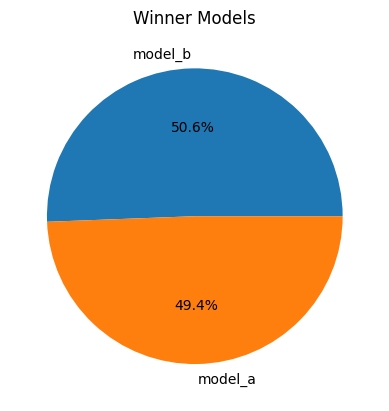

In [38]:
# save the plot
vc = train['winner'].value_counts()

# Print the stats
print("Winner Statistics:")
print("------------------")
print(vc)
print("\nTotal samples:", len(train))
print(f"Win rates:\nmodel_a: {vc['model_a']/len(train)*100:.1f}%")
print(f"model_b: {vc['model_b']/len(train)*100:.1f}%")

# Plot the pie chart
plt.figure()  # Create a new figure
plt.pie(vc.values, labels=vc.index, autopct="%1.1f%%")  # Add percentages to pie slices
plt.title('Winner Models')
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/model_a_wins_vs_model_b_wins.png")
plt.show()


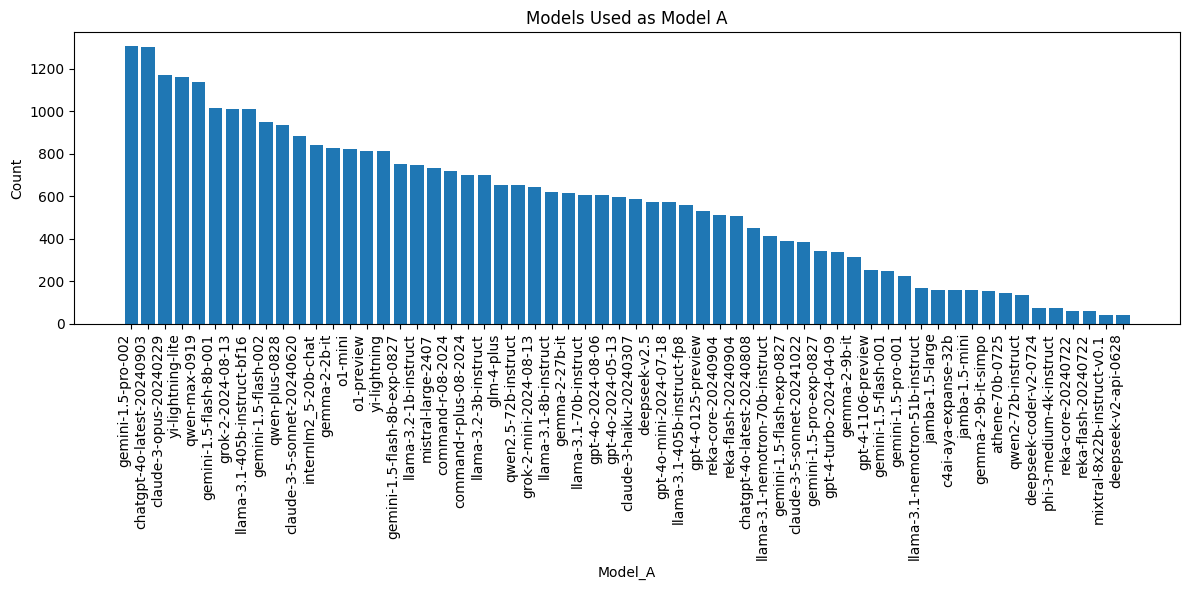

In [39]:
# DataFrame 'train' with the column 'model_a'
vc = train['model_a'].value_counts()  # Count occurrences of each value
# Increase plot size (adjust width and height as needed)
plt.figure(figsize=(12, 6))  # Set width to 12, height to 6
# Create a bar chart
plt.bar(vc.index, vc.values)  # Use index for category labels
# Customize the bar chart for better visualization
plt.xlabel('Model_A')
plt.ylabel('Count')
plt.title('Models Used as Model A')
plt.xticks(rotation=90, ha='right')  # Rotate category labels for readability
plt.tight_layout()  # Adjust spacing to prevent overlapping elements

plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/model_a_counts.png")
plt.show()


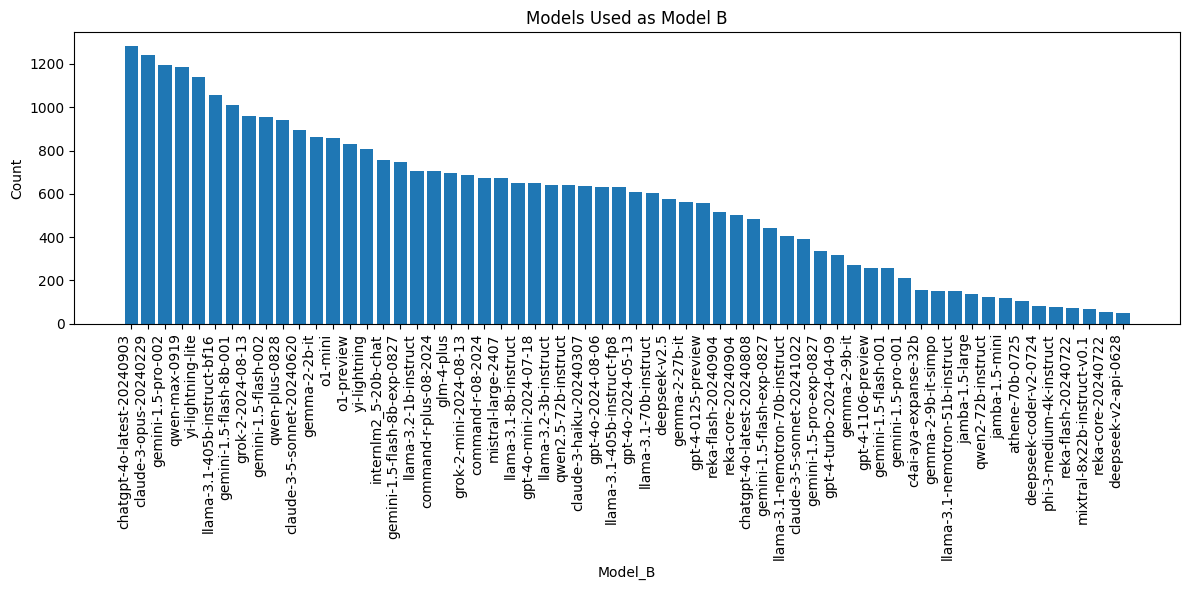

In [46]:
# DataFrame 'train' with the column 'model_a'
vc = train['model_b'].value_counts()  # Count occurrences of each value
# Increase plot size (adjust width and height as needed)
plt.figure(figsize=(12, 6))  # Set width to 12, height to 6
# Create a bar chart
plt.bar(vc.index, vc.values)  # Use index for category labels
# Customize the bar chart for better visualization
plt.xlabel('Model_B')
plt.ylabel('Count')
plt.title('Models Used as Model B')
plt.xticks(rotation=90, ha='right')  # Rotate category labels for readability
plt.tight_layout()  # Adjust spacing to prevent overlapping elements

plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/model_b_counts.png")
plt.show()


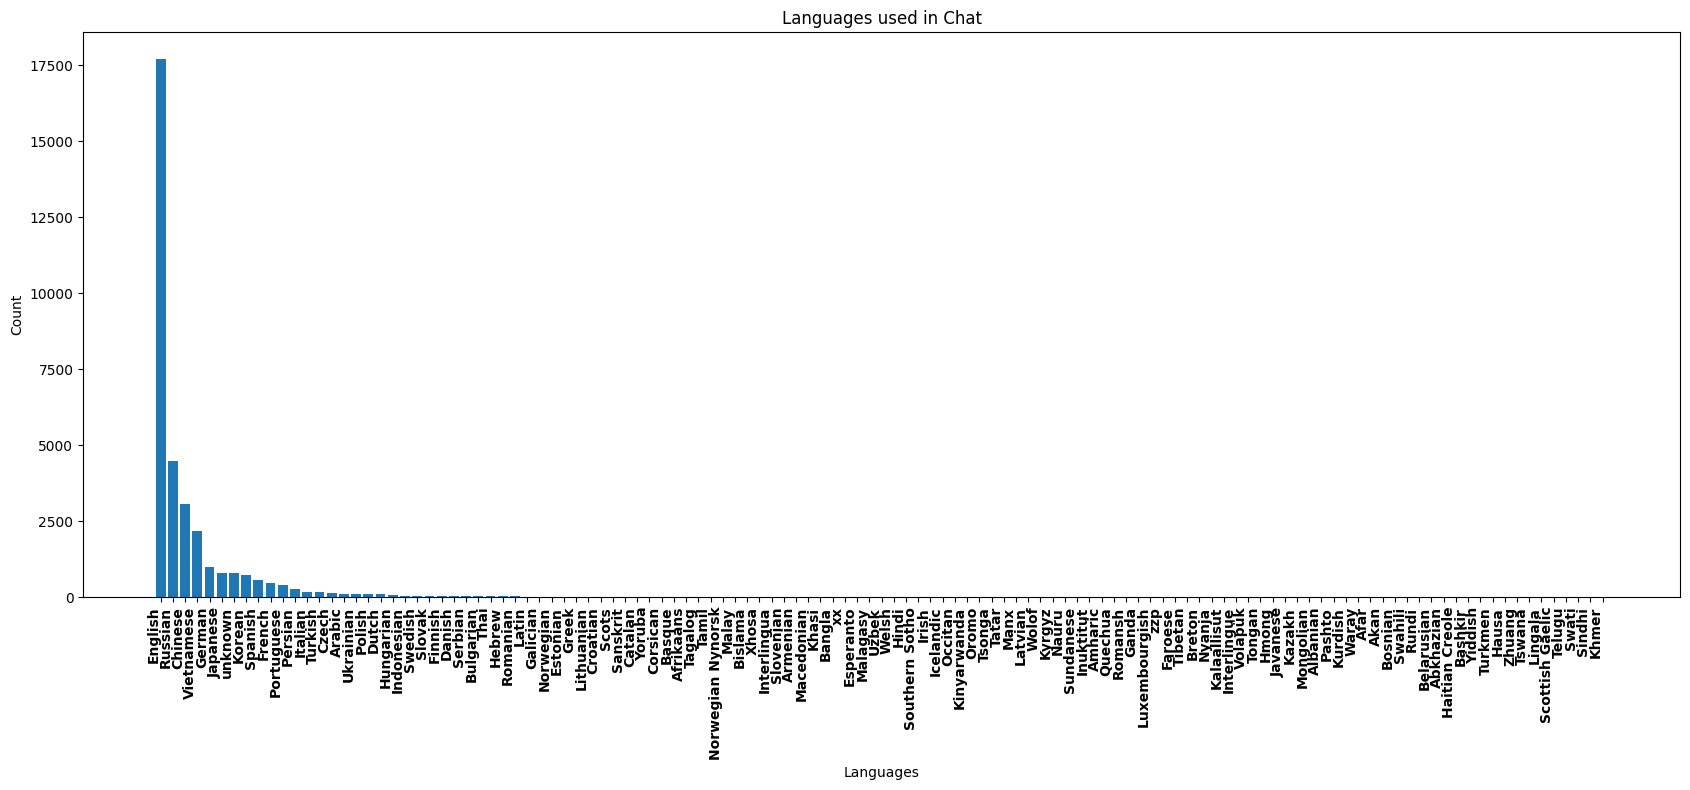

In [40]:
# DataFrame 'train' with the column 'language'
vc = train['language'].value_counts()  # Count occurrences of each value
# Increase plot size (adjust width and height as needed)
plt.figure(figsize=(17, 8))  # Set width to 17, height to 8
# Create a bar chart
plt.bar(vc.index, vc.values)  # Use index for category labels
# Customize the bar chart for better visualization
plt.xlabel('Languages')
plt.ylabel('Count')
plt.title('Languages used in Chat')
plt.xticks(rotation=90, ha='right', fontweight='bold')  # Rotate category labels for readability
plt.tight_layout()  # Adjust spacing to prevent overlapping elements

plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/languages_used_in_chat.png")
plt.show()


# Prompt Length Analysis

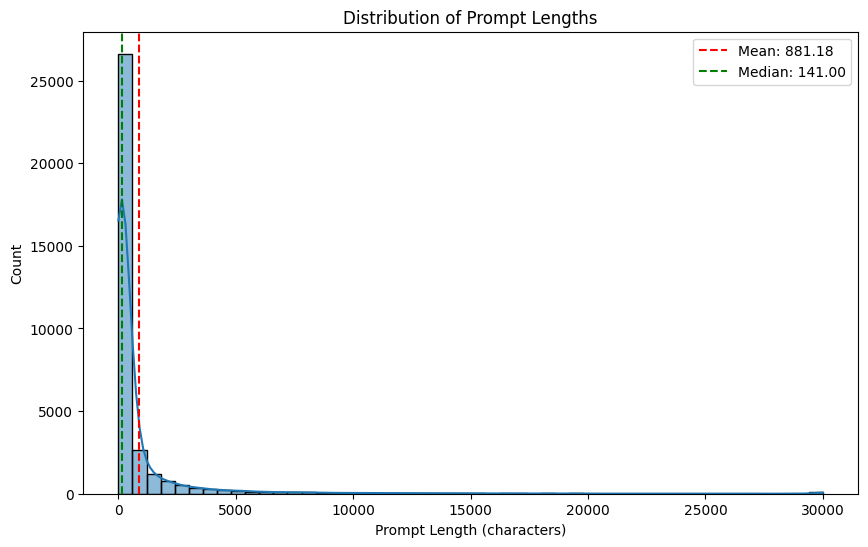


Prompt length statistics:
Mean: 881.18
Median: 141.00
Standard deviation: 2728.16

Shortest prompts:
      prompt  prompt_length  language
525        마              1    Korean
674        в              1   unknown
3712       好              1  Japanese
7314       接              1  Japanese
16392                     1   unknown

Longest prompts:
                                                prompt  prompt_length language
98   # Copyright 2024 The HuggingFace Inc. team. Al...          30000  English
254  You are an expert in reviewing EB2 NIW petitio...          30000  English
667  \n\nДобрый день. напиши реализации встроенных ...          30000  unknown
766  请说中文，分析下面的代码，说一下，为什么在 pinch 的时候这么顺滑？\n我们要做一些变动...          30000  English
926  "You are Rep Name: Puneet Kataria\nRep Role: F...          30000  English


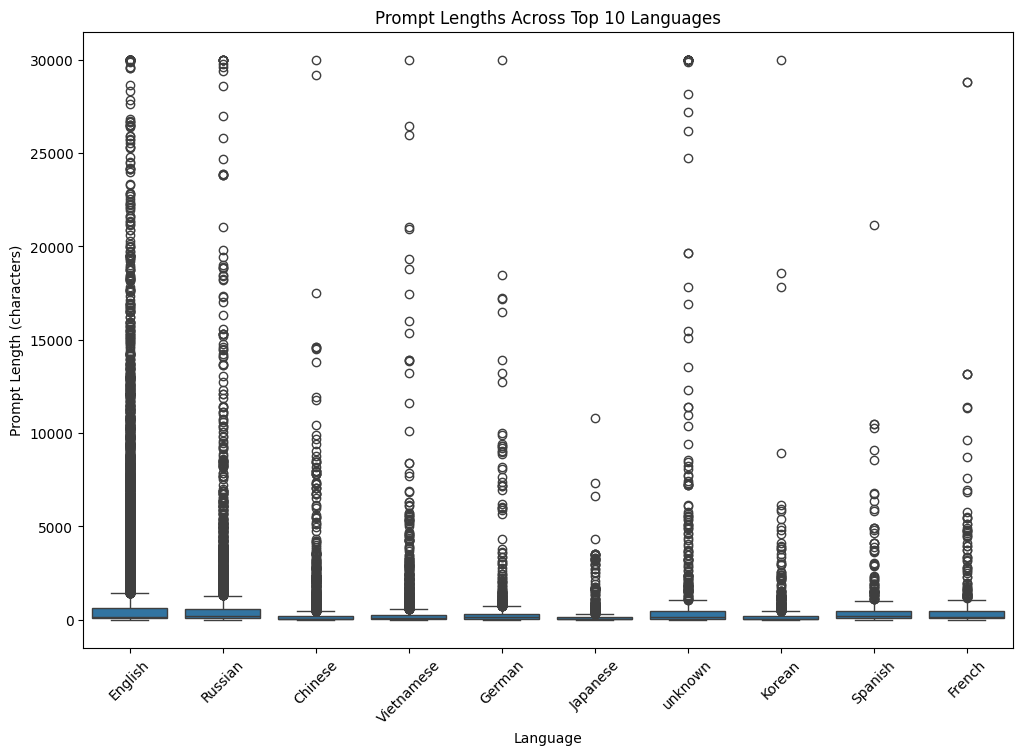


Prompt length statistics by language (top 10):

English:
Mean: 1040.29
Median: 175.00
Std: 2968.50
Count: 17699

Russian:
Mean: 912.59
Median: 181.00
Std: 2609.54
Count: 4491

Chinese:
Mean: 392.58
Median: 54.00
Std: 1434.92
Count: 3053

Vietnamese:
Mean: 520.04
Median: 110.00
Std: 1812.88
Count: 2165

German:
Mean: 610.28
Median: 127.00
Std: 2021.97
Count: 988

Japanese:
Mean: 288.81
Median: 54.00
Std: 790.51
Count: 808

unknown:
Mean: 1579.28
Median: 124.00
Std: 5094.34
Count: 793

Korean:
Mean: 430.00
Median: 43.00
Std: 1675.29
Count: 723

Spanish:
Mean: 628.28
Median: 201.00
Std: 1561.03
Count: 548

French:
Mean: 900.19
Median: 153.00
Std: 2593.57
Count: 453

Prompt length statistics by language (top 15):
                   mean  median  count
language                              
English     1040.287022   175.0  17699
Russian      912.594077   181.0   4491
Chinese      392.577465    54.0   3053
Vietnamese   520.037413   110.0   2165
German       610.283401   127.0    988
Japanes

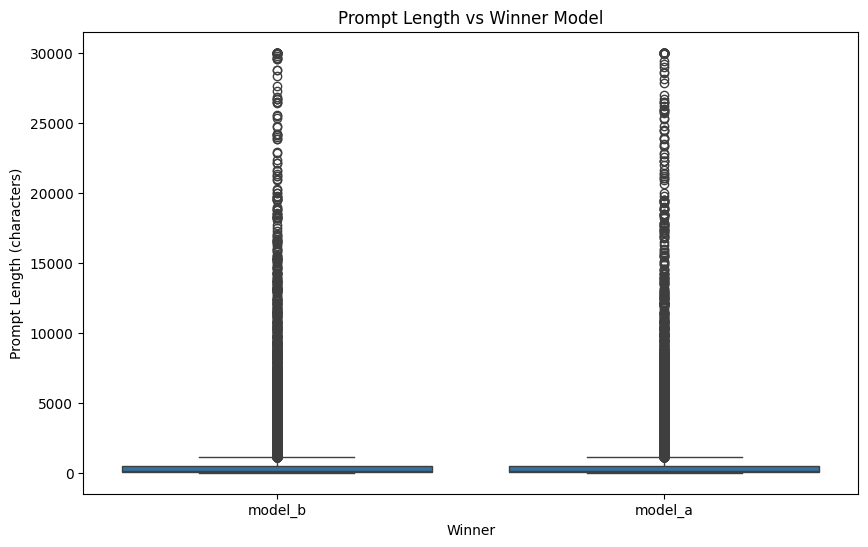


Prompt length statistics by winner:

model_a:
Mean: 905.67
Median: 140.00
Std: 2812.71
Count: 16795

model_b:
Mean: 857.27
Median: 143.00
Std: 2642.87
Count: 17205

T-test for prompt length difference between winners:
t-statistic: 1.6344, p-value: 0.1022
Mean length when model_a wins: 905.67
Mean length when model_b wins: 857.27

Prompt length percentiles:
10th percentile: 29.00
25th percentile: 58.00
50th percentile: 141.00
75th percentile: 473.00
90th percentile: 1887.00
95th percentile: 3972.00
99th percentile: 13860.13

Win rates by length bin:
winner       model_a   model_b
length_bin                    
0-50        0.493506  0.506494
51-100      0.496584  0.503416
101-200     0.497644  0.502356
201-500     0.483518  0.516482
501-1000    0.490573  0.509427
1001-5000   0.495765  0.504235
5000+       0.515766  0.484234

Sample counts by length bin:
length_bin
0-50         7315
51-100       6587
101-200      5942
201-500      5946
501-1000     2864
1001-5000    4014
5000+        133

/var/folders/km/v4q056sj06dbw_y1mlwjg46w0000gn/T/ipykernel_8832/3811326945.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_win_rates = train.groupby('length_bin')['winner'].value_counts(normalize=True).unstack().fillna(0)


<Figure size 1200x600 with 0 Axes>

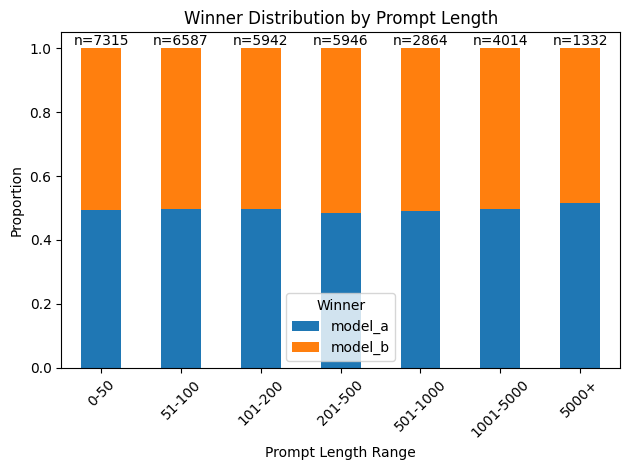


Top models being analyzed:
['yi-lightning-lite', 'grok-2-2024-08-13', 'llama-3.1-405b-instruct-bf16', 'gemini-1.5-flash-002', 'qwen-max-0919', 'claude-3-opus-20240229', 'gemini-1.5-pro-002', 'chatgpt-4o-latest-20240903', 'qwen-plus-0828', 'gemini-1.5-flash-8b-001']

Combined model performance statistics (regardless of position):
                          model  win_rate  mean_prompt_length  count
0             yi-lightning-lite  0.509336          829.924881   2303
1             grok-2-2024-08-13  0.642857          879.575988   1974
2  llama-3.1-405b-instruct-bf16  0.543783          766.151427   2067
3          gemini-1.5-flash-002  0.545597         1002.751048   1908
4                 qwen-max-0919  0.520448          935.291864   2323
5        claude-3-opus-20240229  0.457368          923.504967   2416
6            gemini-1.5-pro-002  0.604800         1091.087200   2500
7    chatgpt-4o-latest-20240903  0.715391          926.281516   2586
8                qwen-plus-0828  0.408413      

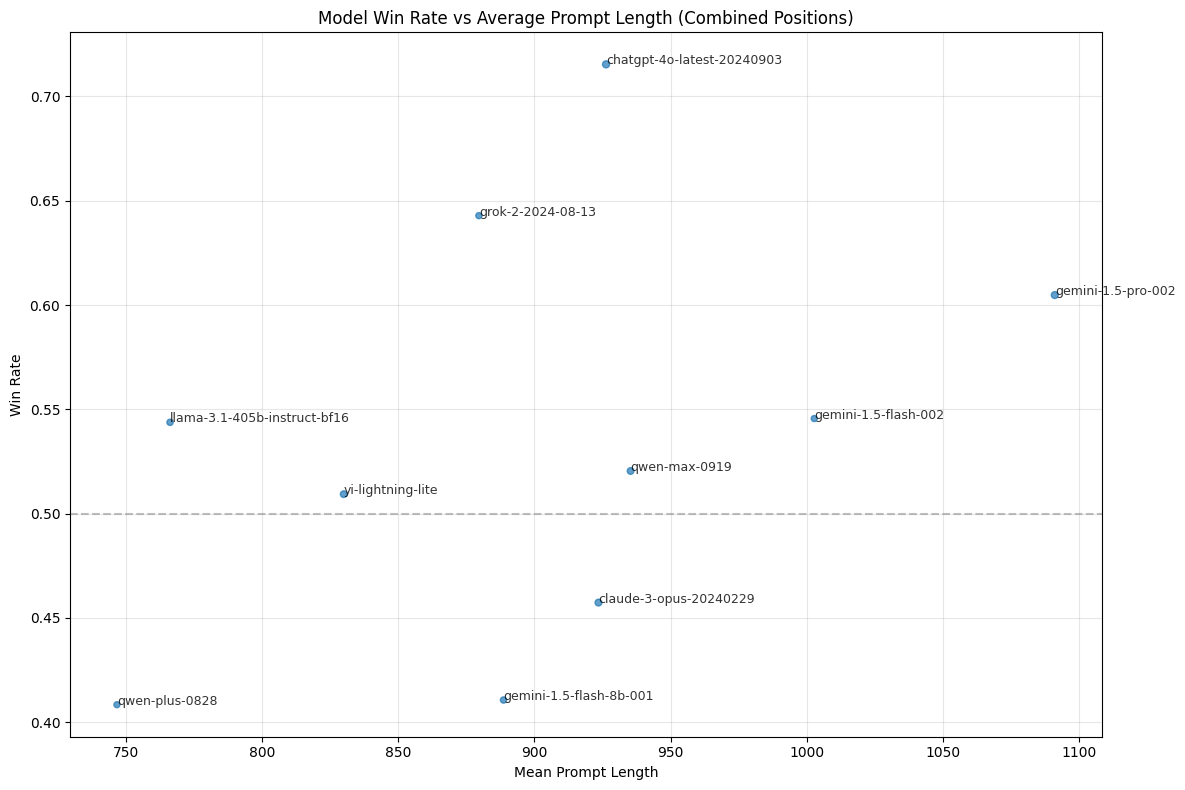

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Calculate prompt lengths
train['prompt_length'] = train['prompt'].apply(len)

# 1. Distribution of prompt lengths
plt.figure(figsize=(10, 6))
sns.histplot(train['prompt_length'], bins=50, kde=True)
plt.title('Distribution of Prompt Lengths')
plt.xlabel('Prompt Length (characters)')
plt.ylabel('Count')
plt.axvline(train['prompt_length'].mean(), color='r', linestyle='--', label=f'Mean: {train["prompt_length"].mean():.2f}')
plt.axvline(train['prompt_length'].median(), color='g', linestyle='--', label=f'Median: {train["prompt_length"].median():.2f}')
plt.legend()
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/prompt_length_distribution.png")
plt.show()

print("\nPrompt length statistics:")
print(f"Mean: {train['prompt_length'].mean():.2f}")
print(f"Median: {train['prompt_length'].median():.2f}")
print(f"Standard deviation: {train['prompt_length'].std():.2f}")

# Look at very short and very long prompts
print("\nShortest prompts:")
print(train.nsmallest(5, 'prompt_length')[['prompt', 'prompt_length', 'language']])
print("\nLongest prompts:")
print(train.nlargest(5, 'prompt_length')[['prompt', 'prompt_length', 'language']])

# 2. Prompt lengths across different languages
# Focus on top languages to avoid clutter
top_languages = train['language'].value_counts().nlargest(10).index
lang_subset = train[train['language'].isin(top_languages)]

plt.figure(figsize=(12, 8))
sns.boxplot(x='language', y='prompt_length', data=lang_subset, order=lang_subset['language'].value_counts().index)
plt.title('Prompt Lengths Across Top 10 Languages')
plt.xlabel('Language')
plt.ylabel('Prompt Length (characters)')
plt.xticks(rotation=45)
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/prompt_length_by_language.png")
plt.show()

print("\nPrompt length statistics by language (top 10):")
for lang in top_languages:
    subset = lang_subset[lang_subset['language'] == lang]
    print(f"\n{lang}:")
    print(f"Mean: {subset['prompt_length'].mean():.2f}")
    print(f"Median: {subset['prompt_length'].median():.2f}")
    print(f"Std: {subset['prompt_length'].std():.2f}")
    print(f"Count: {len(subset)}")

# Calculate mean and median prompt length per language
lang_lengths = train.groupby('language')['prompt_length'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False).head(15)
print("\nPrompt length statistics by language (top 15):")
print(lang_lengths)

# 3. Correlation between prompt length and winner model
plt.figure(figsize=(10, 6))
sns.boxplot(x='winner', y='prompt_length', data=train)
plt.title('Prompt Length vs Winner Model')
plt.xlabel('Winner')
plt.ylabel('Prompt Length (characters)')
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/prompt_length_vs_winner.png")
plt.show()

print("\nPrompt length statistics by winner:")
for winner in ['model_a', 'model_b']:
    subset = train[train['winner'] == winner]
    print(f"\n{winner}:")
    print(f"Mean: {subset['prompt_length'].mean():.2f}")
    print(f"Median: {subset['prompt_length'].median():.2f}")
    print(f"Std: {subset['prompt_length'].std():.2f}")
    print(f"Count: {len(subset)}")

# Statistical test for difference in prompt length between winners
from scipy import stats
model_a_lengths = train[train['winner'] == 'model_a']['prompt_length']
model_b_lengths = train[train['winner'] == 'model_b']['prompt_length']
t_stat, p_value = stats.ttest_ind(model_a_lengths, model_b_lengths, equal_var=False)
print(f"\nT-test for prompt length difference between winners:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print(f"Mean length when model_a wins: {model_a_lengths.mean():.2f}")
print(f"Mean length when model_b wins: {model_b_lengths.mean():.2f}")

# Prompt length percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nPrompt length percentiles:")
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(train['prompt_length'], p):.2f}")

# Length bins and winner analysis
train['length_bin'] = pd.cut(train['prompt_length'], bins=[0, 50, 100, 200, 500, 1000, 5000, np.inf], 
                             labels=['0-50', '51-100', '101-200', '201-500', '501-1000', '1001-5000', '5000+'])
length_win_rates = train.groupby('length_bin')['winner'].value_counts(normalize=True).unstack().fillna(0)
length_counts = train['length_bin'].value_counts().sort_index()

print("\nWin rates by length bin:")
print(length_win_rates)
print("\nSample counts by length bin:")
print(length_counts)

# Plot win rate by length bin
plt.figure(figsize=(12, 6))
length_win_rates.plot(kind='bar', stacked=True)
plt.title('Winner Distribution by Prompt Length')
plt.xlabel('Prompt Length Range')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
for i, count in enumerate(length_counts):
    plt.text(i, 1.01, f'n={count}', ha='center')
plt.legend(title='Winner')
plt.tight_layout()
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/winner_distribution_by_length.png")
plt.show()

# Model-specific analysis
# Look at top 10 most common models
top_models_a = train['model_a'].value_counts().nlargest(10).index
top_models_b = train['model_b'].value_counts().nlargest(10).index
top_models = list(set(list(top_models_a) + list(top_models_b)))

print("\nTop models being analyzed:")
print(top_models)

# Create a dataframe for model performance by prompt length - Combined approach
model_length_data = []

# Analyze models regardless of position
for model in top_models:
    # Data where model is in position A
    subset_a = train[train['model_a'] == model]
    win_count_a = sum(subset_a['winner'] == 'model_a')
    total_a = len(subset_a)
    
    # Data where model is in position B
    subset_b = train[train['model_b'] == model]
    win_count_b = sum(subset_b['winner'] == 'model_b')
    total_b = len(subset_b)
    
    # Combined stats
    total_samples = total_a + total_b
    if total_samples > 50:  # Only consider models with enough samples
        combined_win_rate = (win_count_a + win_count_b) / total_samples
        combined_mean_length = (subset_a['prompt_length'].sum() + subset_b['prompt_length'].sum()) / total_samples
        
        model_length_data.append({
            'model': model,
            'win_rate': combined_win_rate,
            'mean_prompt_length': combined_mean_length,
            'count': total_samples
        })

model_length_df = pd.DataFrame(model_length_data)

print("\nCombined model performance statistics (regardless of position):")
print(model_length_df)

# Plot model win rates vs prompt length (combined)
plt.figure(figsize=(12, 8))
plt.scatter(model_length_df['mean_prompt_length'], model_length_df['win_rate'], 
            s=model_length_df['count']/100, alpha=0.7)

# Add labels for each point
for _, row in model_length_df.iterrows():
    plt.annotate(row['model'], (row['mean_prompt_length'], row['win_rate']), 
                 fontsize=9, alpha=0.8)

plt.title('Model Win Rate vs Average Prompt Length (Combined Positions)')
plt.xlabel('Mean Prompt Length')
plt.ylabel('Win Rate')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/plots/model_win_rate_vs_length_combined.png")
plt.show()


# Response Length

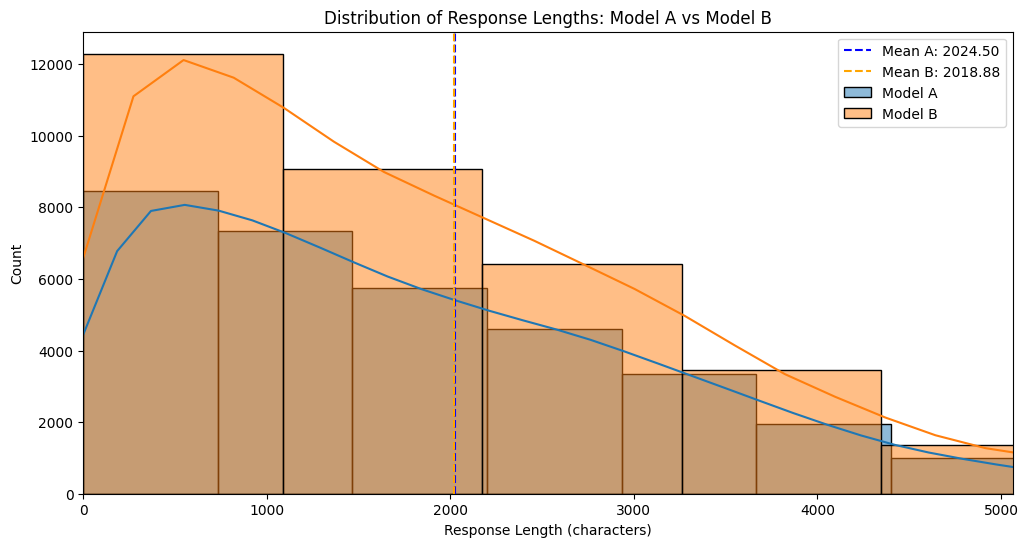


Response length statistics:
Model A: Mean = 2024.50, Median = 1607.00
Model B: Mean = 2018.88, Median = 1608.00

T-test for response length difference between models A and B:
t-statistic: 0.3881, p-value: 0.6980


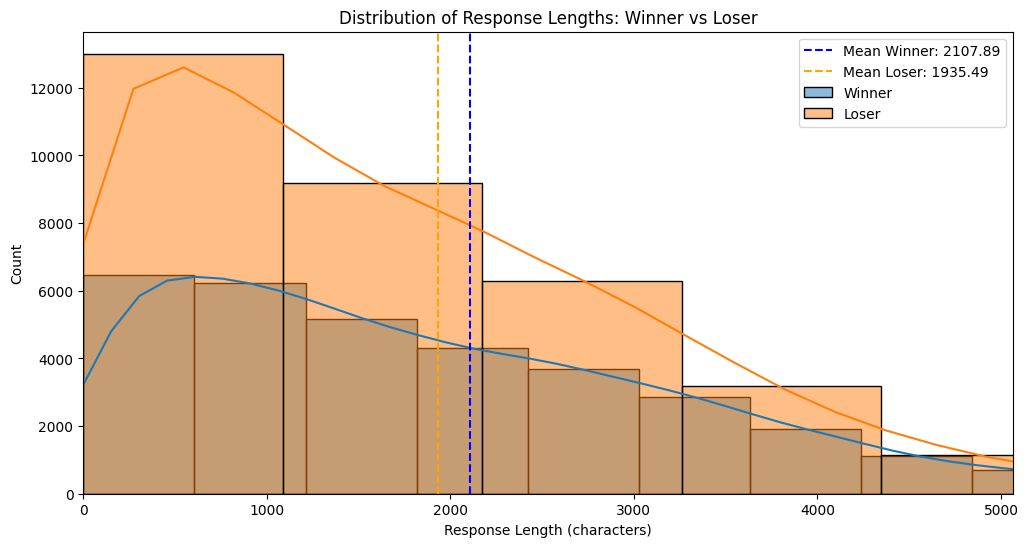


T-test for response length difference between winners and losers:
t-statistic: 11.9019, p-value: 0.0000
Mean length of winning responses: 2107.89
Mean length of losing responses: 1935.49


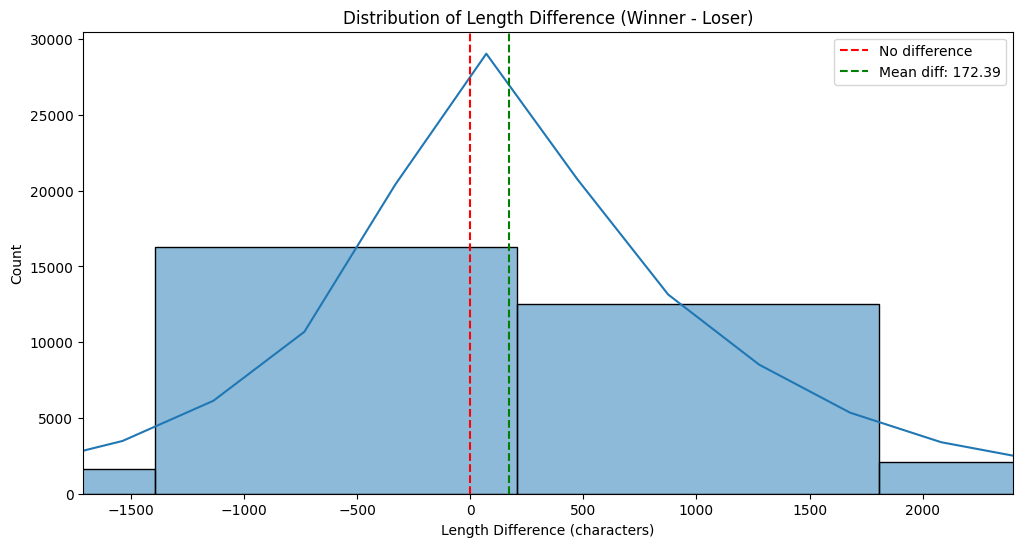


Length difference statistics:
Mean: 172.39
Median: 122.00
Std Dev: 1863.14


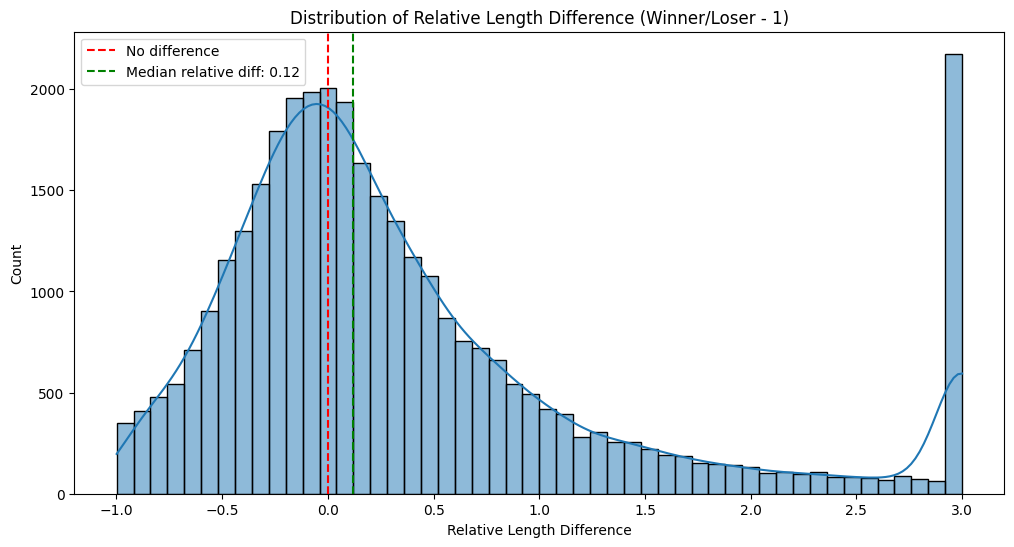


Relative length difference statistics:
Mean: 1.45
Median: 0.12
Std Dev: 34.44

Win rate of model with longer response: 0.5854


<Figure size 1200x600 with 0 Axes>

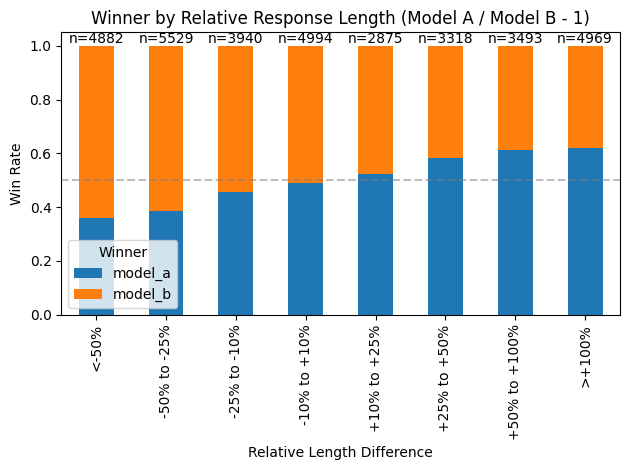


Win rates by relative length difference bins:
winner                model_a   model_b
rel_length_diff_bin                    
<-50%                0.360508  0.639492
-50% to -25%         0.386508  0.613492
-25% to -10%         0.457614  0.542386
-10% to +10%         0.490388  0.509612
+10% to +25%         0.521739  0.478261
+25% to +50%         0.581073  0.418927
+50% to +100%        0.610650  0.389350
>+100%               0.620849  0.379151

Sample counts per bin:
rel_length_diff_bin
<-50%            4882
-50% to -25%     5529
-25% to -10%     3940
-10% to +10%     4994
+10% to +25%     2875
+25% to +50%     3318
+50% to +100%    3493
>+100%           4969
Name: count, dtype: int64

Response length statistics by language:
            language  response_a_length  response_b_length  winner_length  \
62          Malagasy        3026.750000        2505.250000    2931.500000   
59        Lithuanian        2958.000000        1425.300000    1518.500000   
1               Afar        2441.00

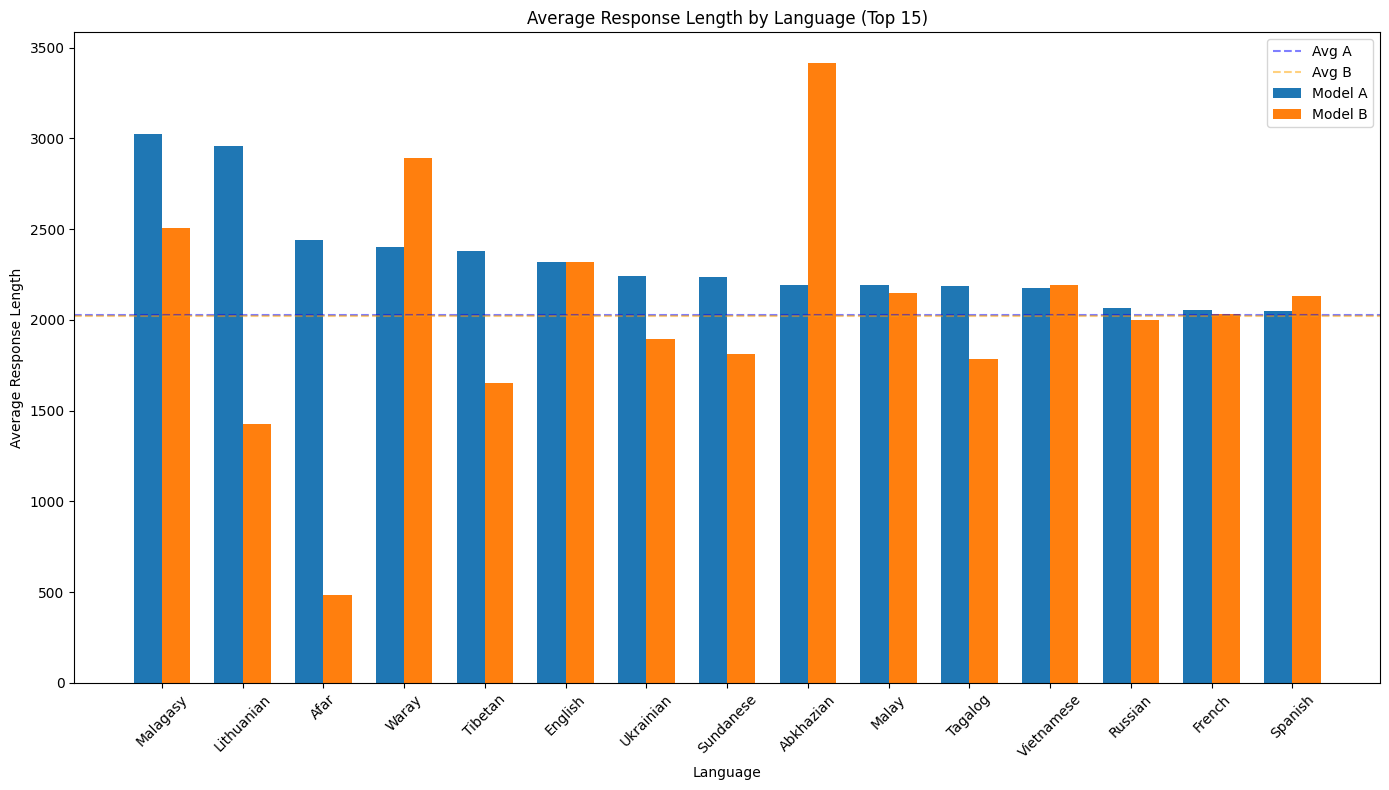

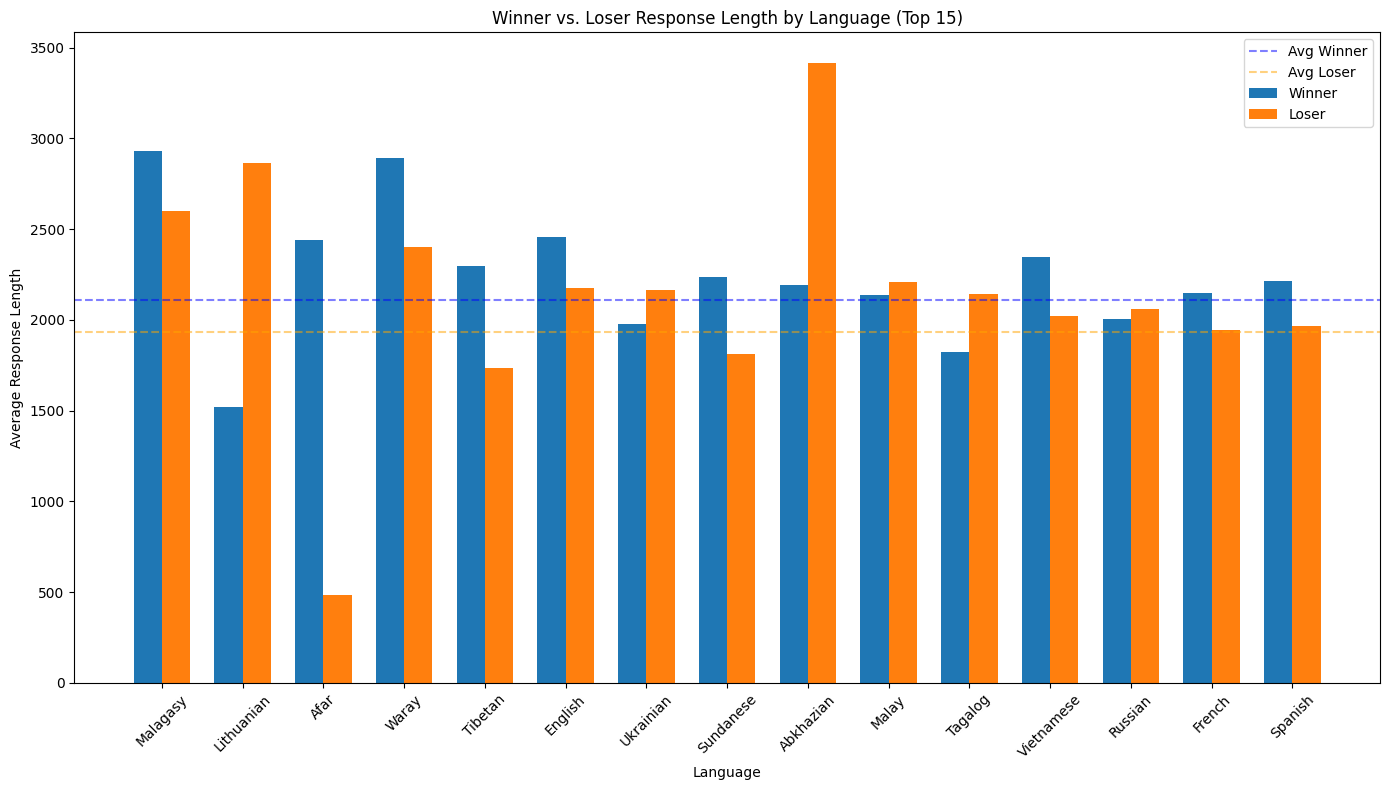

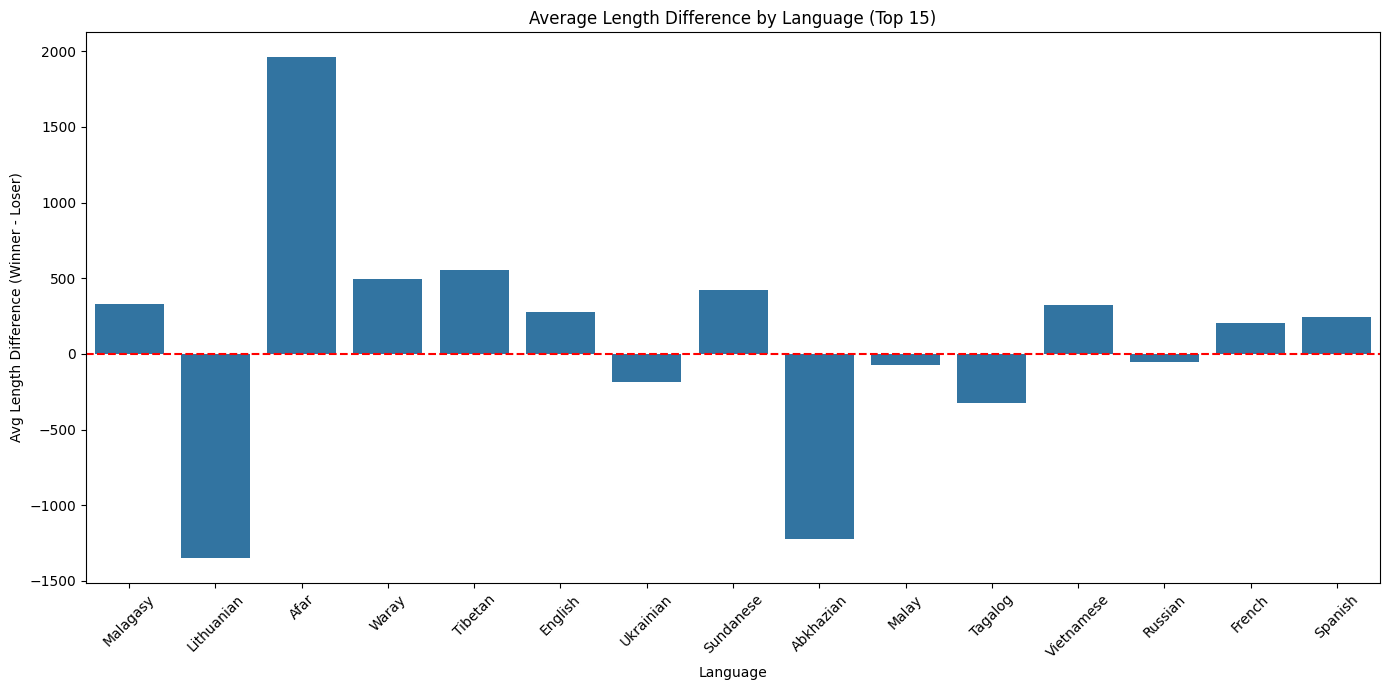


Length statistics by language and winner:
      language   winner  response_a_length  response_b_length  winner_length  \
0    Abkhazian  model_a        2194.000000         3414.00000     2194.00000   
1         Afar  model_a        2441.000000          481.00000     2441.00000   
2    Afrikaans  model_a        1653.800000          793.60000     1653.80000   
3    Afrikaans  model_b        1497.000000         2105.00000     2105.00000   
4         Akan  model_b         138.000000          133.00000      133.00000   
..         ...      ...                ...                ...            ...   
197    unknown  model_b        2075.708134         2123.12201     2123.12201   
198         xx  model_a         608.500000          197.00000      608.50000   
199         xx  model_b         254.500000          421.00000      421.00000   
200        zzp  model_a          56.000000          265.00000       56.00000   
201        zzp  model_b         191.000000          147.00000      147.00000 

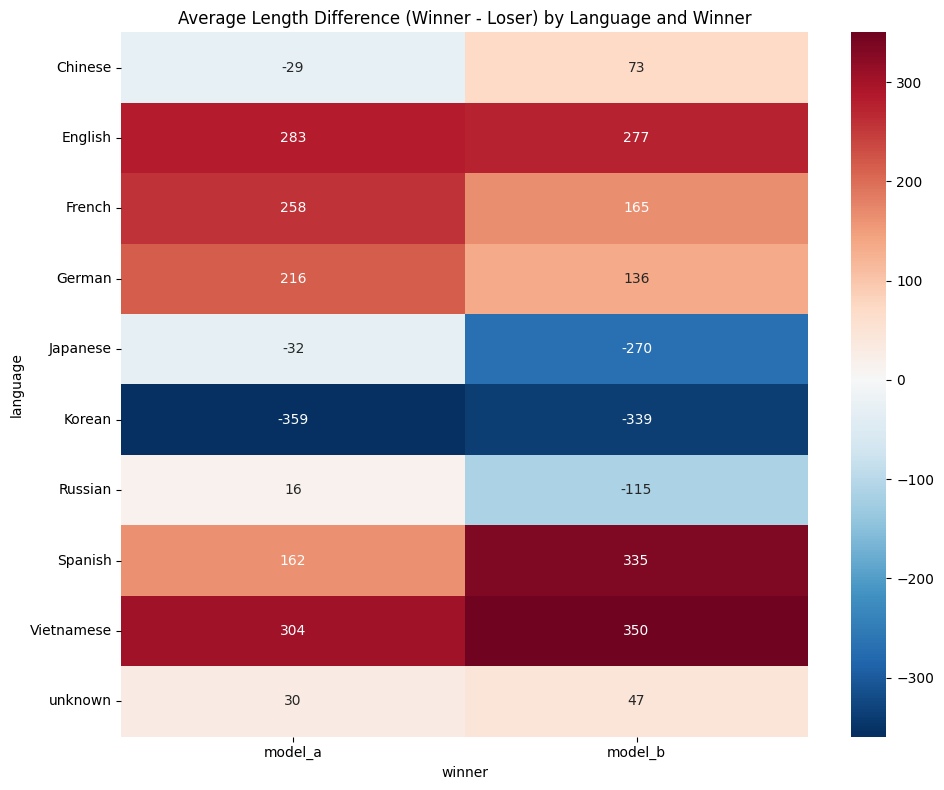


Length difference pivot table by language and winner:
winner         model_a     model_b
language                          
Chinese     -28.804878   72.654297
English     283.199862  276.829071
French      258.425743  165.462151
German      216.321569  136.182008
Japanese    -31.907500 -270.360294
Korean     -359.263441 -339.410256
Russian      15.629244 -114.705083
Spanish     162.372760  335.089219
Vietnamese  303.639315  350.174242
unknown      30.146667   47.413876


/var/folders/km/v4q056sj06dbw_y1mlwjg46w0000gn/T/ipykernel_8832/3031103034.py:248: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lang_data['winner_numeric'] = (lang_data['winner'] == 'model_a').astype(int)
/var/folders/km/v4q056sj06dbw_y1mlwjg46w0000gn/T/ipykernel_8832/3031103034.py:248: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lang_data['winner_numeric'] = (lang_data['winner'] == 'model_a').astype(int)
/var/folders/km/v4q056sj06dbw_y1mlwjg46w0000gn/T/ipykernel_8832/3031103034.py:248: SettingWithCopyWa

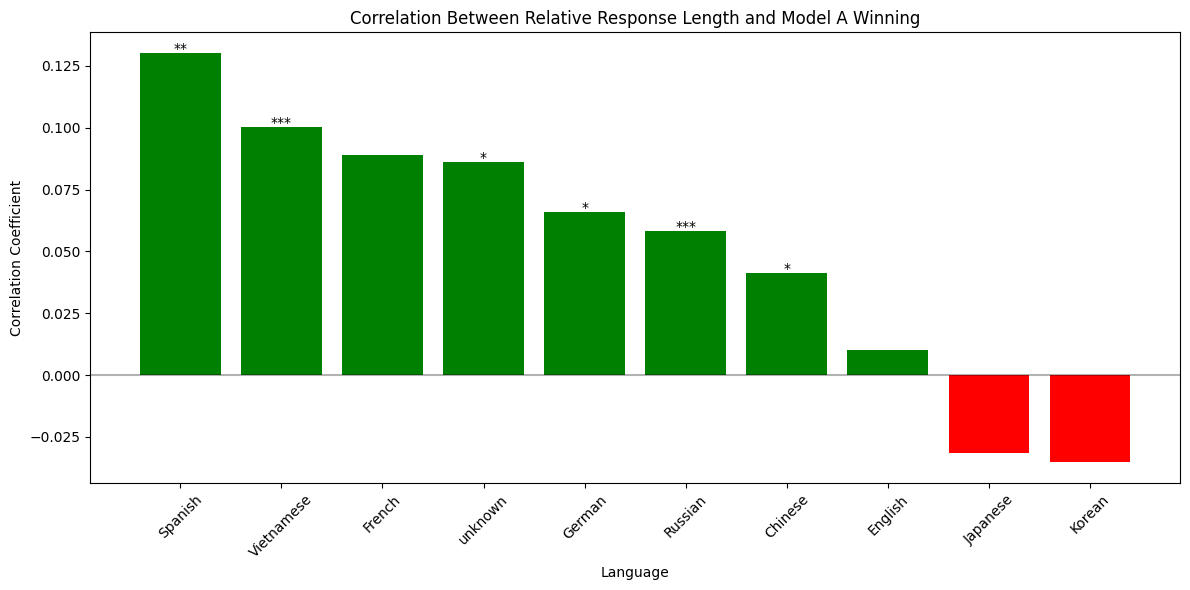


Correlation analysis by language:
     language  correlation   p_value  sample_size
8     Spanish     0.130304  0.002240          548
3  Vietnamese     0.100298  0.000003         2165
9      French     0.089185  0.057863          453
6     unknown     0.086144  0.015245          793
4      German     0.066000  0.038062          988
1     Russian     0.058153  0.000096         4491
2     Chinese     0.041411  0.022128         3053
0     English     0.010347  0.168672        17699
5    Japanese    -0.031636  0.369142          808
7      Korean    -0.035220  0.344319          723

Interpretation guide:
Positive correlation: Model A is more likely to win when its response is longer relative to Model B
Negative correlation: Model A is more likely to win when its response is shorter relative to Model B
* p < 0.05, ** p < 0.01, *** p < 0.001

Languages with strongest correlations:
     language  correlation   p_value  sample_size
8     Spanish     0.130304  0.002240          548
3  Vietnames

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load the data
path = "/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/"

# Calculate response lengths
train['response_a_length'] = train['response_a'].apply(len)
train['response_b_length'] = train['response_b'].apply(len)
train['winner_length'] = train.apply(lambda x: x['response_a_length'] if x['winner'] == 'model_a' else x['response_b_length'], axis=1)
train['loser_length'] = train.apply(lambda x: x['response_b_length'] if x['winner'] == 'model_a' else x['response_a_length'], axis=1)
train['length_diff'] = train['winner_length'] - train['loser_length']
train['relative_length_diff'] = train['length_diff'] / train['loser_length']

# 1. Compare the length of responses between model_a and model_b
plt.figure(figsize=(12, 6))
sns.histplot(train['response_a_length'], bins=50, kde=True, alpha=0.5, label='Model A')
sns.histplot(train['response_b_length'], bins=50, kde=True, alpha=0.5, label='Model B')
plt.axvline(train['response_a_length'].mean(), color='blue', linestyle='--', 
            label=f'Mean A: {train["response_a_length"].mean():.2f}')
plt.axvline(train['response_b_length'].mean(), color='orange', linestyle='--', 
            label=f'Mean B: {train["response_b_length"].mean():.2f}')
plt.title('Distribution of Response Lengths: Model A vs Model B')
plt.xlabel('Response Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.xlim(0, np.percentile(np.concatenate([train['response_a_length'], train['response_b_length']]), 95))  # Trim extreme values
plt.savefig(path + "plots/response_length_distribution.png")
plt.show()

# Summary statistics
print("\nResponse length statistics:")
print(f"Model A: Mean = {train['response_a_length'].mean():.2f}, Median = {train['response_a_length'].median():.2f}")
print(f"Model B: Mean = {train['response_b_length'].mean():.2f}, Median = {train['response_b_length'].median():.2f}")

# Test if there's a significant difference in response lengths
t_stat, p_value = stats.ttest_ind(train['response_a_length'], train['response_b_length'], equal_var=False)
print(f"\nT-test for response length difference between models A and B:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

# 2. Analyze if the winning model tends to give longer or shorter responses
plt.figure(figsize=(12, 6))
sns.histplot(train['winner_length'], bins=50, kde=True, alpha=0.5, label='Winner')
sns.histplot(train['loser_length'], bins=50, kde=True, alpha=0.5, label='Loser')
plt.axvline(train['winner_length'].mean(), color='blue', linestyle='--', 
            label=f'Mean Winner: {train["winner_length"].mean():.2f}')
plt.axvline(train['loser_length'].mean(), color='orange', linestyle='--', 
            label=f'Mean Loser: {train["loser_length"].mean():.2f}')
plt.title('Distribution of Response Lengths: Winner vs Loser')
plt.xlabel('Response Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.xlim(0, np.percentile(np.concatenate([train['winner_length'], train['loser_length']]), 95))  # Trim extreme values
plt.savefig(path + "plots/winner_loser_length_distribution.png")
plt.show()

# Test if winning responses tend to be longer or shorter
t_stat, p_value = stats.ttest_ind(train['winner_length'], train['loser_length'], equal_var=False)
print("\nT-test for response length difference between winners and losers:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print(f"Mean length of winning responses: {train['winner_length'].mean():.2f}")
print(f"Mean length of losing responses: {train['loser_length'].mean():.2f}")

# Length difference distribution
plt.figure(figsize=(12, 6))
sns.histplot(train['length_diff'], bins=50, kde=True)
plt.axvline(0, color='r', linestyle='--', label='No difference')
plt.axvline(train['length_diff'].mean(), color='g', linestyle='--', 
            label=f'Mean diff: {train["length_diff"].mean():.2f}')
plt.title('Distribution of Length Difference (Winner - Loser)')
plt.xlabel('Length Difference (characters)')
plt.ylabel('Count')
plt.legend()
plt.xlim(np.percentile(train['length_diff'], 5), np.percentile(train['length_diff'], 95))  # Trim extreme values
plt.savefig(path + "plots/length_difference_distribution.png")
plt.show()

print(f"\nLength difference statistics:")
print(f"Mean: {train['length_diff'].mean():.2f}")
print(f"Median: {train['length_diff'].median():.2f}")
print(f"Std Dev: {train['length_diff'].std():.2f}")

# Relative length difference
plt.figure(figsize=(12, 6))
sns.histplot(train['relative_length_diff'].clip(-1, 3), bins=50, kde=True)  # Clip to remove extreme values
plt.axvline(0, color='r', linestyle='--', label='No difference')
plt.axvline(train['relative_length_diff'].median(), color='g', linestyle='--', 
            label=f'Median relative diff: {train["relative_length_diff"].median():.2f}')
plt.title('Distribution of Relative Length Difference (Winner/Loser - 1)')
plt.xlabel('Relative Length Difference')
plt.ylabel('Count')
plt.legend()
plt.savefig(path + "plots/relative_length_difference_distribution.png")
plt.show()

print(f"\nRelative length difference statistics:")
print(f"Mean: {train['relative_length_diff'].mean():.2f}")
print(f"Median: {train['relative_length_diff'].median():.2f}")
print(f"Std Dev: {train['relative_length_diff'].std():.2f}")

# Calculate win rates based on which model gave a longer response
train['longer_response'] = np.where(train['response_a_length'] > train['response_b_length'], 'model_a', 'model_b')
longer_response_win_rate = (train['longer_response'] == train['winner']).mean()
print(f"\nWin rate of model with longer response: {longer_response_win_rate:.4f}")

# Win rate by relative length difference bins
train['rel_length_diff_bin'] = pd.cut(
    np.clip(train['response_a_length'] / train['response_b_length'] - 1, -0.99, 3), 
    bins=[-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1, 3],
    labels=['<-50%', '-50% to -25%', '-25% to -10%', '-10% to +10%', '+10% to +25%', '+25% to +50%', '+50% to +100%', '>+100%']
)

length_diff_win_rates = pd.crosstab(train['rel_length_diff_bin'], train['winner'], normalize='index')
plt.figure(figsize=(12, 6))
length_diff_win_rates.plot(kind='bar', stacked=True)
plt.title('Winner by Relative Response Length (Model A / Model B - 1)')
plt.xlabel('Relative Length Difference')
plt.ylabel('Win Rate')
bin_counts = train['rel_length_diff_bin'].value_counts().sort_index()
for i, count in enumerate(bin_counts):
    plt.text(i, 1.01, f'n={count}', ha='center')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Winner')
plt.tight_layout()
plt.savefig(path + "plots/win_rate_by_length_difference.png")
plt.show()

print("\nWin rates by relative length difference bins:")
print(length_diff_win_rates)
print("\nSample counts per bin:")
print(bin_counts)

# 3. Look at response length differences by language
# Focus on top languages
top_languages = train['language'].value_counts().nlargest(10).index
lang_subset = train[train['language'].isin(top_languages)]

# Calculate average response lengths by language
lang_lengths = train.groupby('language').agg({
    'response_a_length': 'mean',
    'response_b_length': 'mean',
    'winner_length': 'mean',
    'loser_length': 'mean',
    'length_diff': 'mean'
}).reset_index()

lang_lengths = lang_lengths.sort_values('response_a_length', ascending=False)

print("\nResponse length statistics by language:")
print(lang_lengths)

# Plot response lengths by language
plt.figure(figsize=(14, 8))
x = np.arange(len(lang_lengths.head(15)))
width = 0.35
plt.bar(x - width/2, lang_lengths.head(15)['response_a_length'], width, label='Model A')
plt.bar(x + width/2, lang_lengths.head(15)['response_b_length'], width, label='Model B')
plt.axhline(train['response_a_length'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg A')
plt.axhline(train['response_b_length'].mean(), color='orange', linestyle='--', alpha=0.5, label='Avg B')
plt.xlabel('Language')
plt.ylabel('Average Response Length')
plt.title('Average Response Length by Language (Top 15)')
plt.xticks(x, lang_lengths.head(15)['language'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(path + "plots/response_length_by_language.png")
plt.show()

# Winner vs. loser length by language
plt.figure(figsize=(14, 8))
x = np.arange(len(lang_lengths.head(15)))
width = 0.35
plt.bar(x - width/2, lang_lengths.head(15)['winner_length'], width, label='Winner')
plt.bar(x + width/2, lang_lengths.head(15)['loser_length'], width, label='Loser')
plt.axhline(train['winner_length'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Winner')
plt.axhline(train['loser_length'].mean(), color='orange', linestyle='--', alpha=0.5, label='Avg Loser')
plt.xlabel('Language')
plt.ylabel('Average Response Length')
plt.title('Winner vs. Loser Response Length by Language (Top 15)')
plt.xticks(x, lang_lengths.head(15)['language'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(path + "plots/winner_loser_length_by_language.png")
plt.show()

# Length difference by language
plt.figure(figsize=(14, 7))
sns.barplot(x='language', y='length_diff', data=lang_lengths.head(15))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Language')
plt.ylabel('Avg Length Difference (Winner - Loser)')
plt.title('Average Length Difference by Language (Top 15)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(path + "plots/length_difference_by_language.png")
plt.show()

# Create a heatmap of length difference by language and winner
language_winner_lengths = train.groupby(['language', 'winner']).agg({
    'response_a_length': 'mean',
    'response_b_length': 'mean',
    'winner_length': 'mean',
    'loser_length': 'mean',
    'length_diff': 'mean',
    'id': 'count'
}).reset_index()

print("\nLength statistics by language and winner:")
print(language_winner_lengths)

# Filter for top languages and meaningful sample sizes
language_winner_lengths = language_winner_lengths[
    (language_winner_lengths['language'].isin(top_languages)) & 
    (language_winner_lengths['id'] > 50)
]

# Create a pivot table for the heatmap
length_diff_pivot = language_winner_lengths.pivot(
    index='language', 
    columns='winner', 
    values='length_diff'
)

plt.figure(figsize=(10, 8))
sns.heatmap(length_diff_pivot, annot=True, cmap="RdBu_r", center=0, fmt=".0f")
plt.title('Average Length Difference (Winner - Loser) by Language and Winner')
plt.tight_layout()
plt.savefig(path + "plots/length_difference_heatmap.png")
plt.show()

print("\nLength difference pivot table by language and winner:")
print(length_diff_pivot)

# Analysis of correlation between response length and win rate by language
lang_corr_data = []
for lang in top_languages:
    lang_data = train[train['language'] == lang]
    
    # Skip languages with too few samples
    if len(lang_data) < 100:
        continue
    
    # Calculate correlation between relative length difference and winner
    # Convert winner to numeric (1 for model_a, 0 for model_b)
    lang_data['winner_numeric'] = (lang_data['winner'] == 'model_a').astype(int)
    
    # Calculate relative length difference (model_a / model_b - 1)
    rel_length_diff = lang_data['response_a_length'] / lang_data['response_b_length'] - 1
    
    # Calculate correlation
    corr, p_value = stats.pearsonr(rel_length_diff, lang_data['winner_numeric'])
    
    lang_corr_data.append({
        'language': lang,
        'correlation': corr,
        'p_value': p_value,
        'sample_size': len(lang_data)
    })

lang_corr_df = pd.DataFrame(lang_corr_data)
lang_corr_df = lang_corr_df.sort_values('correlation', ascending=False)

# Plot correlation by language
plt.figure(figsize=(12, 6))
bars = plt.bar(
    lang_corr_df['language'], 
    lang_corr_df['correlation'], 
    color=[('green' if c > 0 else 'red') for c in lang_corr_df['correlation']]
)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Language')
plt.ylabel('Correlation Coefficient')
plt.title('Correlation Between Relative Response Length and Model A Winning')
plt.xticks(rotation=45)

# Add significance indicators
for i, p in enumerate(lang_corr_df['p_value']):
    if p < 0.001:
        plt.text(i, lang_corr_df['correlation'].iloc[i], '***', ha='center')
    elif p < 0.01:
        plt.text(i, lang_corr_df['correlation'].iloc[i], '**', ha='center')
    elif p < 0.05:
        plt.text(i, lang_corr_df['correlation'].iloc[i], '*', ha='center')

plt.tight_layout()
plt.savefig(path + "plots/length_correlation_by_language.png")
plt.show()

print("\nCorrelation analysis by language:")
print(lang_corr_df)

print("\nInterpretation guide:")
print("Positive correlation: Model A is more likely to win when its response is longer relative to Model B")
print("Negative correlation: Model A is more likely to win when its response is shorter relative to Model B")
print("* p < 0.05, ** p < 0.01, *** p < 0.001")

print("\nLanguages with strongest correlations:")
print(lang_corr_df[['language', 'correlation', 'p_value', 'sample_size']].head(5))
print("\nLanguages with strongest negative correlations:")
print(lang_corr_df[['language', 'correlation', 'p_value', 'sample_size']].tail(5))


Model Statistics Summary:
       appearances         wins   win_rate
count    60.000000    60.000000  60.000000
mean   1133.333333   566.666667   0.479936
std     686.932229   410.799744   0.128366
min      90.000000    32.000000   0.123024
25%     508.000000   237.250000   0.406310
50%    1207.500000   478.500000   0.489382
75%    1602.500000   765.500000   0.574573
max    2586.000000  1850.000000   0.715391

Top 10 models by win rate:
                         model  appearances  wins  win_rate
20  chatgpt-4o-latest-20240903         2586  1850  0.715391
14                  o1-preview         1647  1172  0.711597
23  chatgpt-4o-latest-20240808          936   633  0.676282
10                     o1-mini         1682  1127  0.670036
47     gemini-1.5-pro-exp-0827          681   451  0.662261
4            grok-2-2024-08-13         1974  1269  0.642857
43                yi-lightning         1622  1008  0.621455
19          gemini-1.5-pro-002         2500  1512  0.604800
44   gemini-1.5-fl

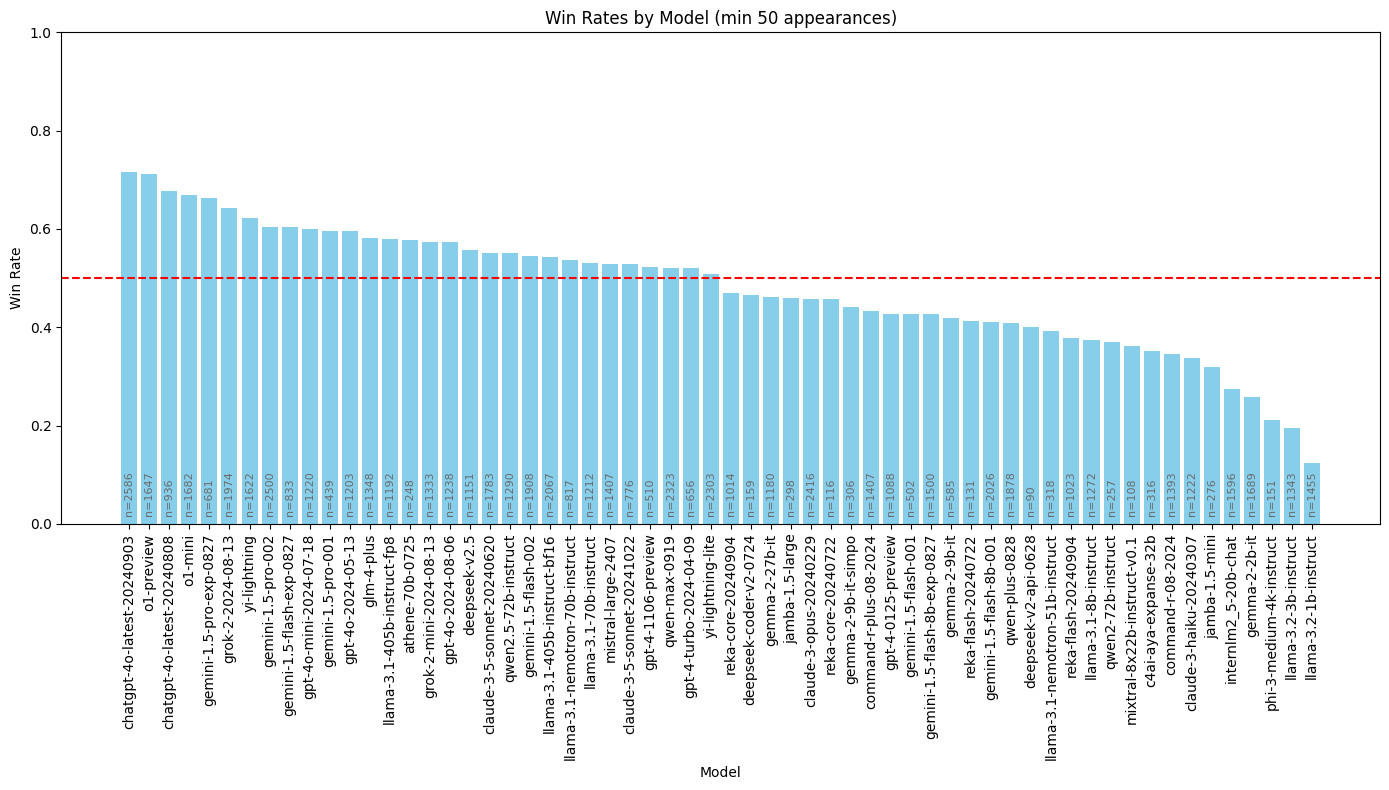

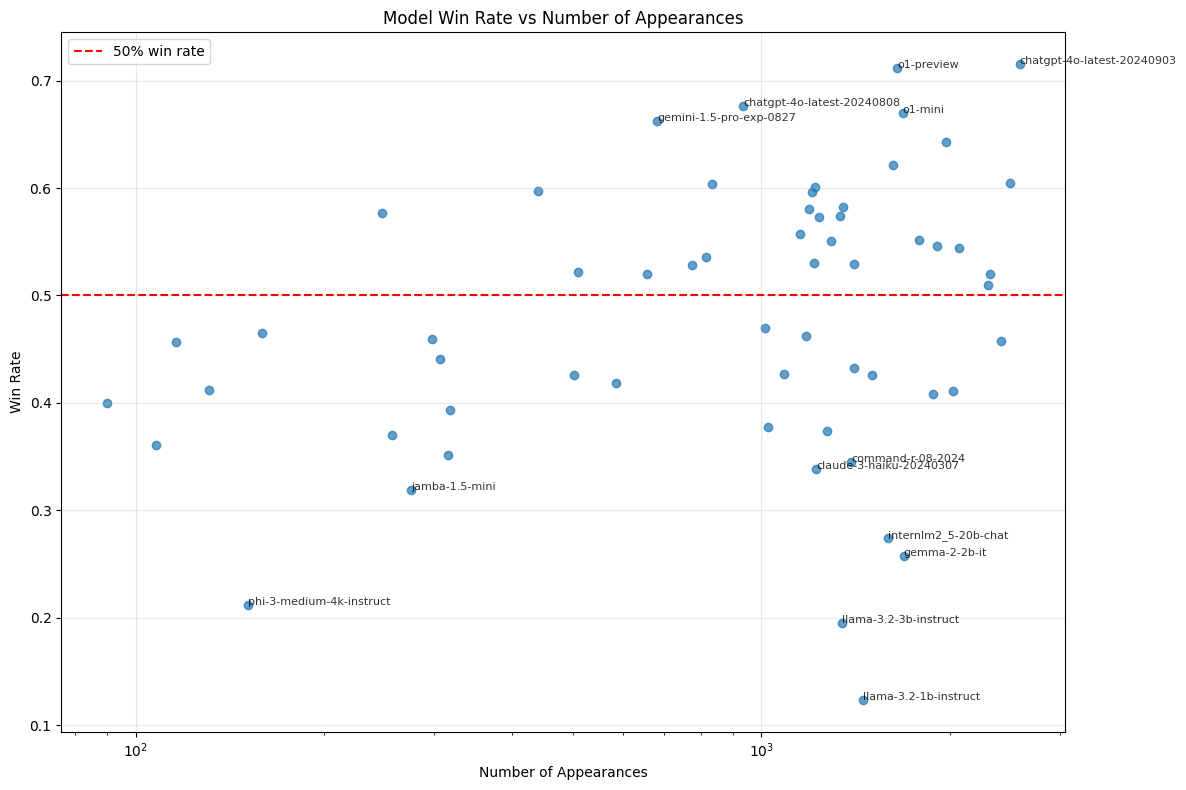


Head-to-head data summary:
           matches       wins_a   win_rate_a
count  2734.000000  2734.000000  2734.000000
mean     12.435991     6.143014     0.493348
std      11.867982     6.858325     0.278859
min       1.000000     0.000000     0.000000
25%       4.000000     2.000000     0.310884
50%       9.000000     4.000000     0.500000
75%      17.000000     8.000000     0.666667
max      72.000000    65.000000     1.000000


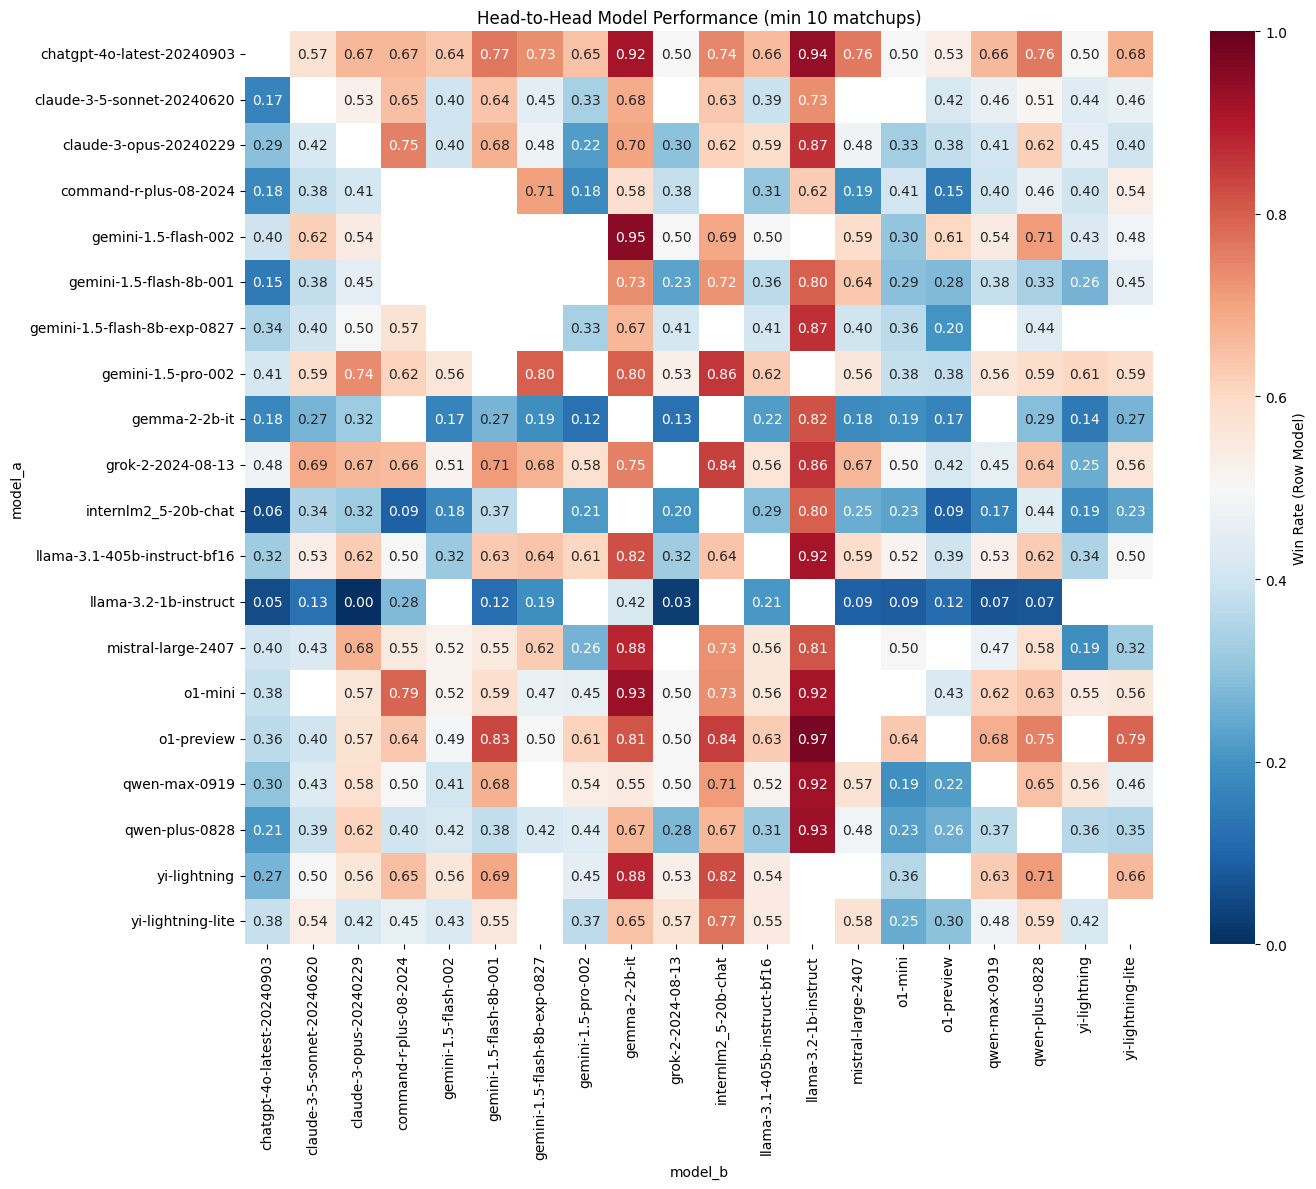

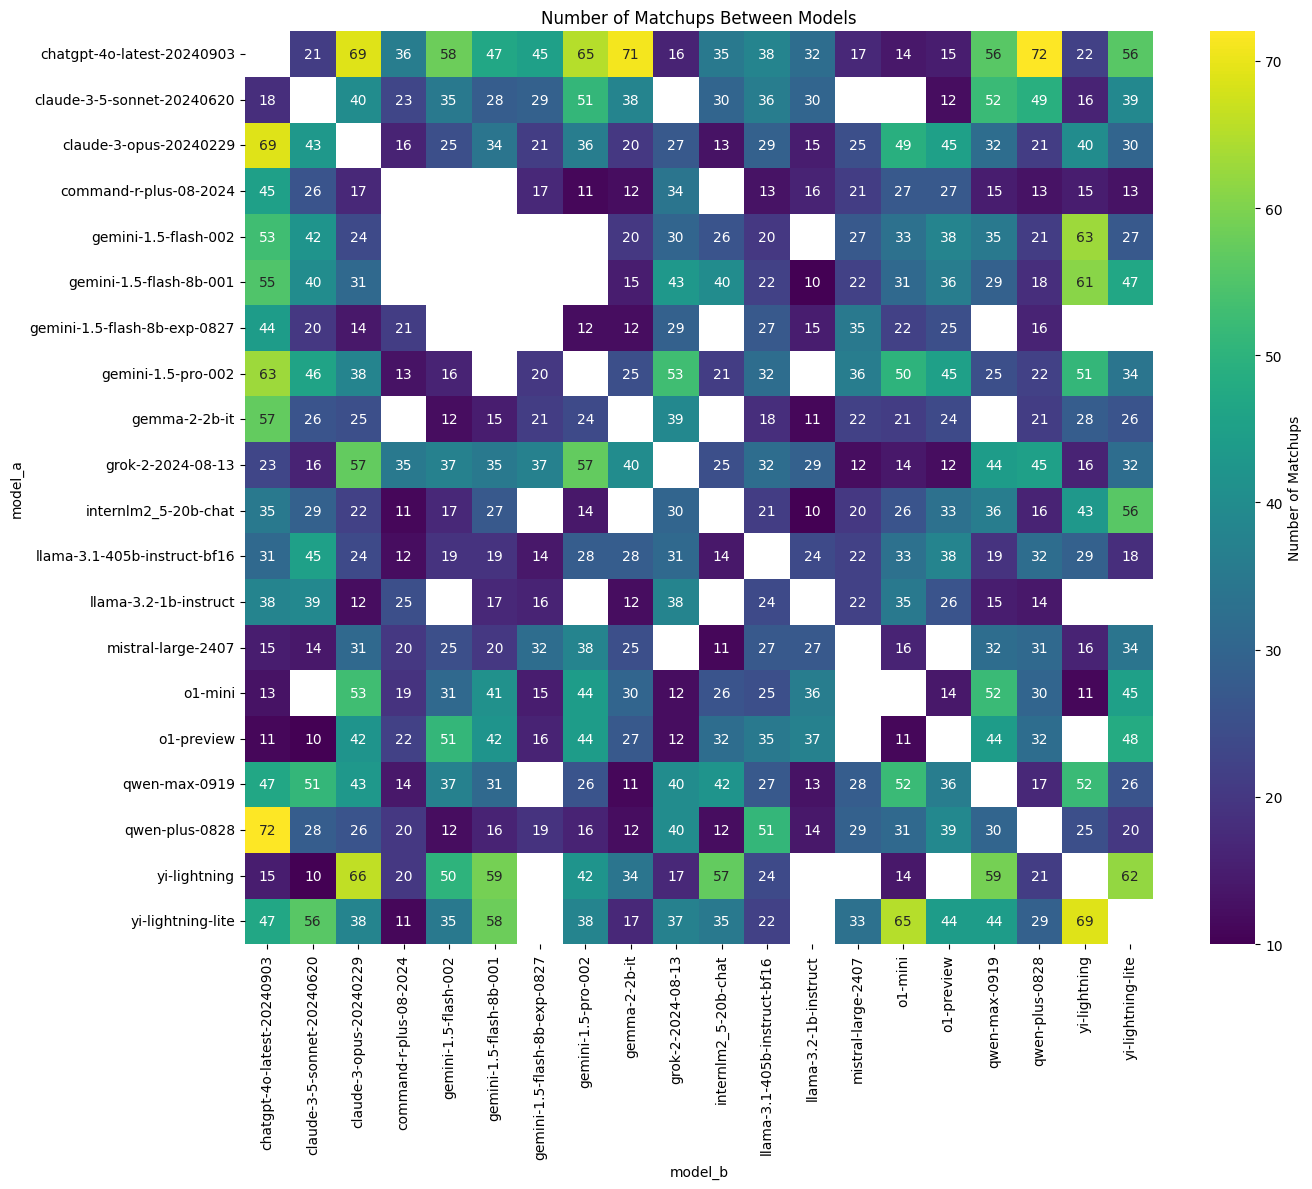


Model consistency statistics:
       avg_win_rate  win_rate_std  num_opponents  total_matches
count     56.000000     53.000000      56.000000      56.000000
mean       0.484969      0.165059      22.875000     497.446429
std        0.144968      0.044965      12.507543     344.676339
min        0.100000      0.035252       1.000000      10.000000
25%        0.419076      0.147095      13.750000     207.250000
50%        0.527093      0.163791      25.500000     479.500000
75%        0.576007      0.186054      32.000000     710.250000
max        0.700204      0.348490      43.000000    1291.000000

Most consistently strong models:
                        model_a  avg_win_rate  win_rate_std  num_opponents  \
18      gemini-1.5-pro-exp-0827      0.700204      0.163791             14   
45                   o1-preview      0.685823      0.167285             27   
3    chatgpt-4o-latest-20240903      0.684915      0.125986             41   
2    chatgpt-4o-latest-20240808      0.684060  

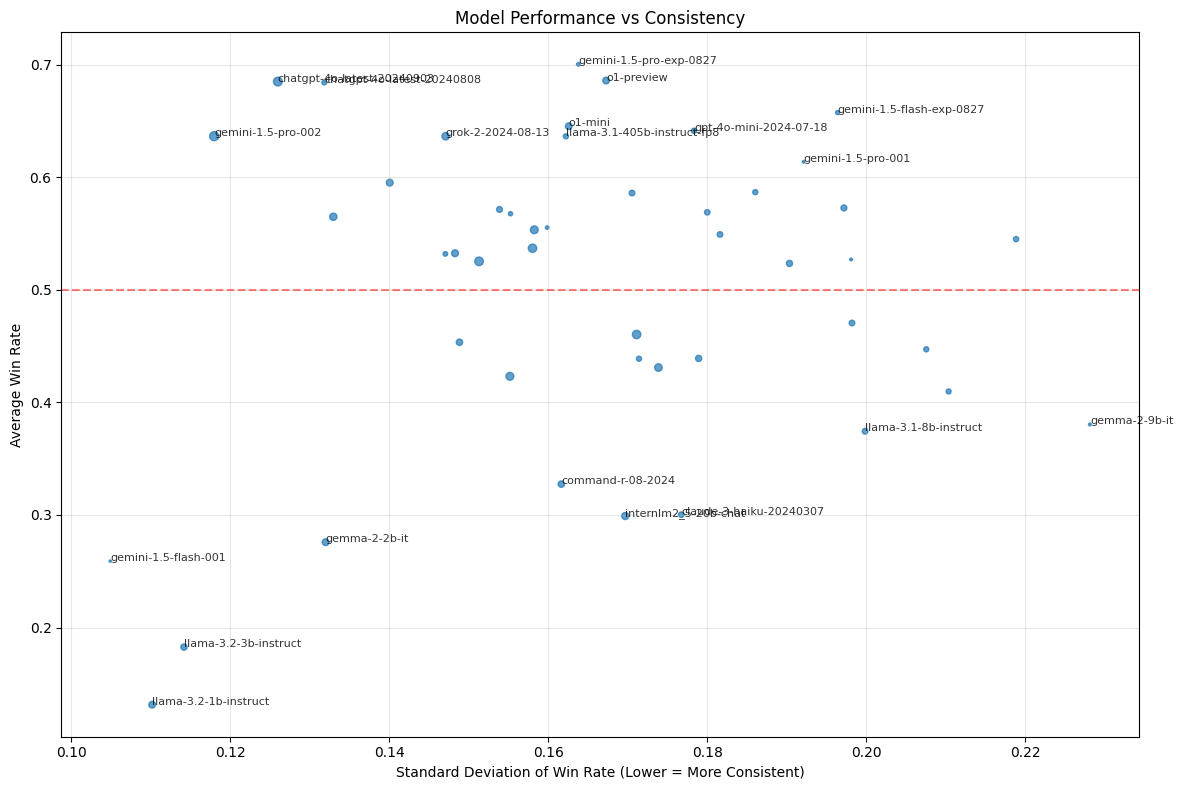


Dominance statistics:
       total_opponents  dominated_opponents  dominance_ratio  avg_win_rate
count        47.000000            47.000000        47.000000     47.000000
mean         26.829787             9.297872         0.360082      0.504622
std           9.346748             6.883865         0.230261      0.136601
min           6.000000             0.000000         0.000000      0.131493
25%          21.500000             5.000000         0.166360      0.434845
50%          27.000000             9.000000         0.380952      0.536881
75%          34.000000            12.000000         0.510000      0.590917
max          43.000000            31.000000         0.857143      0.700204

Models with highest dominance ratio (consistently beat other models):
                          model  total_opponents  dominated_opponents  \
45      gemini-1.5-pro-exp-0827               14                   12   
11   chatgpt-4o-latest-20240808               23                   19   
16   chatgpt

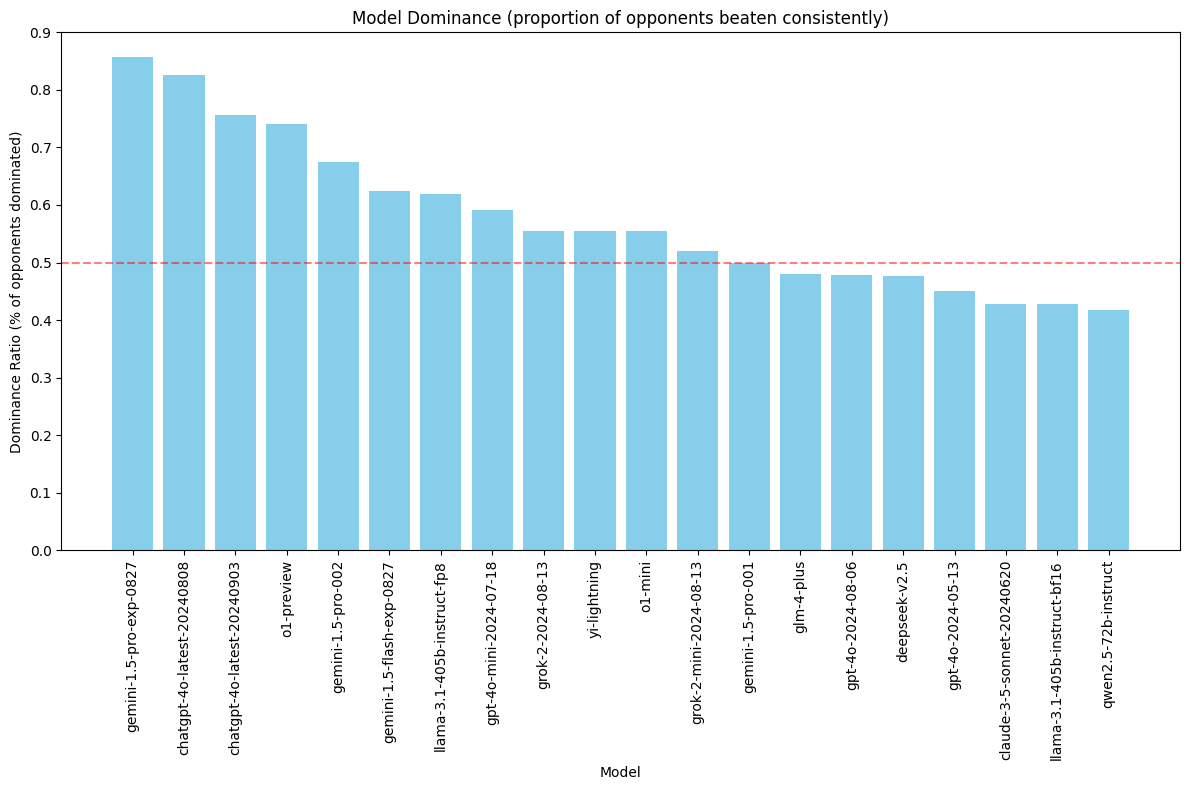


Performance by model family:
      family  avg_win_rate  median_win_rate  model_count  total_appearances
13        o1      0.690816         0.690816            2               3329
7       grok      0.608375         0.608375            2               3307
5        glm      0.582344         0.582344            1               1348
6        gpt      0.578632         0.584354            8               9437
0     athene      0.576613         0.576613            1                248
18        yi      0.565395         0.565395            2               3925
3     gemini      0.534533         0.571204            8              10389
11   mistral      0.529495         0.529495            1               1407
2   deepseek      0.474105         0.465409            3               1400
1     claude      0.468892         0.492859            4               6197
16      qwen      0.462225         0.464430            4               5748
17      reka      0.428965         0.434555            4  

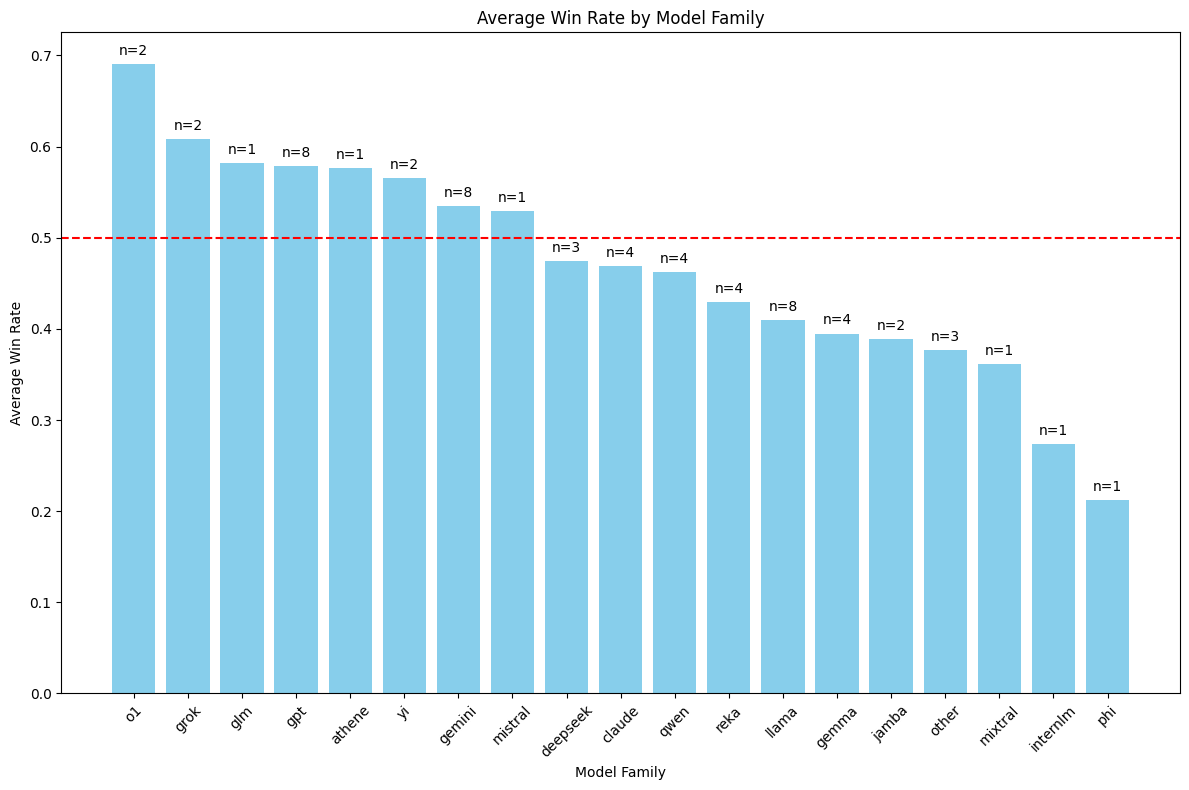

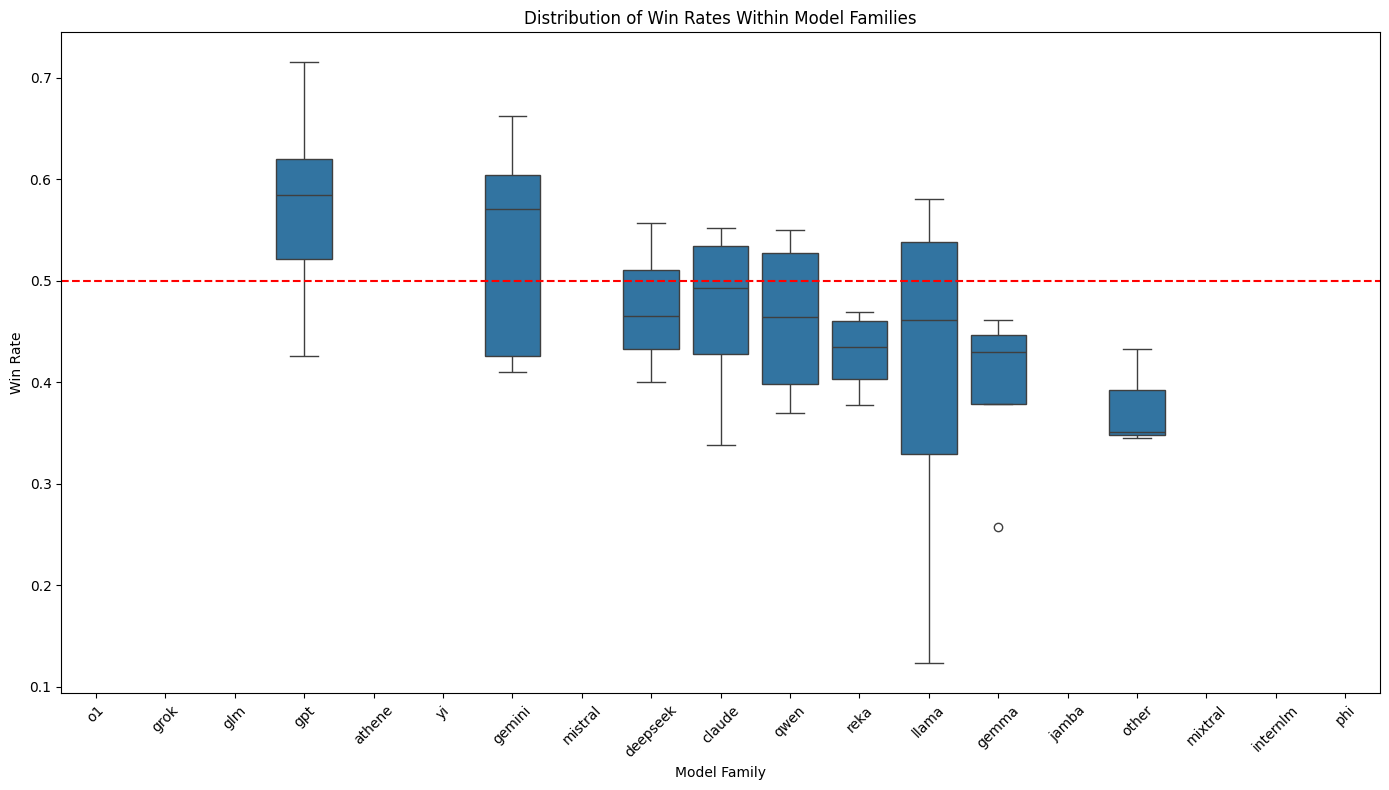

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load the data
path = "/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/"
# train = pd.read_parquet(path+"train.parquet")

# 1. Calculate win rates for each model
# Create a function to calculate win rate for each model
def calculate_model_stats(df):
    # Create empty dictionaries to store results
    model_appearances = defaultdict(int)
    model_wins = defaultdict(int)
    
    # Count appearances and wins for each model
    for _, row in df.iterrows():
        model_a = row['model_a']
        model_b = row['model_b']
        winner = row['winner']
        
        model_appearances[model_a] += 1
        model_appearances[model_b] += 1
        
        if winner == 'model_a':
            model_wins[model_a] += 1
        else:
            model_wins[model_b] += 1
    
    # Calculate win rate and create DataFrame
    model_stats = []
    for model, appearances in model_appearances.items():
        wins = model_wins[model]
        win_rate = wins / appearances
        model_stats.append({
            'model': model,
            'appearances': appearances,
            'wins': wins,
            'win_rate': win_rate
        })
    
    return pd.DataFrame(model_stats)

# Calculate win rates
model_stats = calculate_model_stats(train)
model_stats = model_stats.sort_values('win_rate', ascending=False)

print("\nModel Statistics Summary:")
print(model_stats.describe())

print("\nTop 10 models by win rate:")
print(model_stats.head(10))
print("\nBottom 10 models by win rate:")
print(model_stats.tail(10))

# Plot win rates for models with sufficient data
min_appearances = 50  # Set a threshold for meaningful results
filtered_stats = model_stats[model_stats['appearances'] >= min_appearances].sort_values('win_rate', ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.bar(filtered_stats['model'], filtered_stats['win_rate'], color='skyblue')
plt.axhline(0.5, color='red', linestyle='--', label='50% win rate')
plt.xlabel('Model')
plt.ylabel('Win Rate')
plt.title(f'Win Rates by Model (min {min_appearances} appearances)')
plt.xticks(rotation=90)
plt.ylim(0, 1)

# Add appearance count annotations
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, 0.02, 
             f"n={filtered_stats['appearances'].iloc[i]}", 
             ha='center', rotation=90, color='dimgray', fontsize=8)

plt.tight_layout()
plt.savefig(path + "plots/model_win_rates.png")
plt.show()

# Plot model win rate vs number of appearances
plt.figure(figsize=(12, 8))
plt.scatter(model_stats['appearances'], model_stats['win_rate'], alpha=0.7)
plt.axhline(0.5, color='red', linestyle='--', label='50% win rate')
plt.xscale('log')  # Log scale for better visualization
plt.xlabel('Number of Appearances')
plt.ylabel('Win Rate')
plt.title('Model Win Rate vs Number of Appearances')
plt.grid(True, alpha=0.3)

# Add annotations for notable models (top performers with many appearances)
for _, row in model_stats[
    (model_stats['win_rate'] > 0.65) & 
    (model_stats['appearances'] > 100)
].iterrows():
    plt.annotate(row['model'], 
                (row['appearances'], row['win_rate']),
                fontsize=8, alpha=0.8)

# Add annotations for poor performers with many appearances
for _, row in model_stats[
    (model_stats['win_rate'] < 0.35) & 
    (model_stats['appearances'] > 100)
].iterrows():
    plt.annotate(row['model'], 
                (row['appearances'], row['win_rate']),
                fontsize=8, alpha=0.8)

plt.legend()
plt.tight_layout()
plt.savefig(path + "plots/win_rate_vs_appearances.png")
plt.show()

# 2. Create a heatmap of model vs model performance
# Function to create head-to-head performance data
def create_head_to_head_data(df):
    # Create a dictionary to track wins and matches
    matches = defaultdict(int)
    wins = defaultdict(int)
    
    # Iterate through each row
    for _, row in df.iterrows():
        model_a = row['model_a']
        model_b = row['model_b']
        winner = row['winner']
        
        # Create a unique key for this matchup
        matchup = (model_a, model_b)
        matches[matchup] += 1
        
        if winner == 'model_a':
            wins[matchup] += 1
    
    # Calculate win rates
    matchup_data = []
    for matchup, match_count in matches.items():
        model_a, model_b = matchup
        wins_a = wins[matchup]
        win_rate_a = wins_a / match_count
        
        matchup_data.append({
            'model_a': model_a,
            'model_b': model_b,
            'matches': match_count,
            'wins_a': wins_a,
            'win_rate_a': win_rate_a
        })
    
    return pd.DataFrame(matchup_data)

# Get head-to-head data
h2h_data = create_head_to_head_data(train)

print("\nHead-to-head data summary:")
print(h2h_data.describe())

# Filter to include only matchups with sufficient data
min_matchups = 10
filtered_h2h = h2h_data[h2h_data['matches'] >= min_matchups]

# Get top models (by appearance) for heatmap
top_models = model_stats.nlargest(20, 'appearances')['model'].tolist()

# Filter to include only matchups between top models
top_h2h = filtered_h2h[
    (filtered_h2h['model_a'].isin(top_models)) & 
    (filtered_h2h['model_b'].isin(top_models))
]

# Create pivot table for heatmap
h2h_pivot = top_h2h.pivot_table(
    index='model_a', 
    columns='model_b', 
    values='win_rate_a',
    aggfunc='mean'
)

# Create a better-looking heatmap with annotations
plt.figure(figsize=(14, 12))
mask = np.isnan(h2h_pivot.values)
ax = sns.heatmap(
    h2h_pivot, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r',
    center=0.5,
    mask=mask,
    vmin=0, 
    vmax=1,
    cbar_kws={'label': 'Win Rate (Row Model)'}
)
plt.title(f'Head-to-Head Model Performance (min {min_matchups} matchups)')
plt.tight_layout()
plt.savefig(path + 'plots/model_h2h_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Create another view showing match counts
h2h_count_pivot = top_h2h.pivot_table(
    index='model_a', 
    columns='model_b', 
    values='matches',
    aggfunc='sum'
)

plt.figure(figsize=(14, 12))
mask = np.isnan(h2h_count_pivot.values)
sns.heatmap(
    h2h_count_pivot, 
    annot=True, 
    fmt='g', 
    cmap='viridis',
    mask=mask,
    cbar_kws={'label': 'Number of Matchups'}
)
plt.title('Number of Matchups Between Models')
plt.tight_layout()
plt.savefig(path + "plots/model_matchup_counts.png")
plt.show()

# 3. Identify which models consistently outperform others
# Calculate model consistency by standard deviation of win rates
model_consistency = filtered_h2h.groupby('model_a').agg(
    avg_win_rate=('win_rate_a', 'mean'),
    win_rate_std=('win_rate_a', 'std'),
    num_opponents=('model_b', 'nunique'),
    total_matches=('matches', 'sum')
).reset_index()

print("\nModel consistency statistics:")
print(model_consistency.describe())

# Filter for models with many opponents
min_opponents = 5
consistent_models = model_consistency[model_consistency['num_opponents'] >= min_opponents]
consistent_models = consistent_models.sort_values('avg_win_rate', ascending=False)

print("\nMost consistently strong models:")
print(consistent_models.head(10)[['model_a', 'avg_win_rate', 'win_rate_std', 'num_opponents', 'total_matches']])

print("\nMost consistently weak models:")
print(consistent_models.tail(10)[['model_a', 'avg_win_rate', 'win_rate_std', 'num_opponents', 'total_matches']])

# Plot win rate vs consistency
plt.figure(figsize=(12, 8))
plt.scatter(
    consistent_models['win_rate_std'], 
    consistent_models['avg_win_rate'],
    s=consistent_models['total_matches']/30,  # Size based on matches
    alpha=0.7
)

plt.xlabel('Standard Deviation of Win Rate (Lower = More Consistent)')
plt.ylabel('Average Win Rate')
plt.title('Model Performance vs Consistency')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Add annotations for notable models
for _, row in consistent_models[
    (consistent_models['avg_win_rate'] > 0.6) | 
    (consistent_models['avg_win_rate'] < 0.4) |
    (consistent_models['win_rate_std'] < 0.1)
].iterrows():
    plt.annotate(row['model_a'], 
                (row['win_rate_std'], row['avg_win_rate']),
                fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig(path + "plots/model_consistency.png")
plt.show()

# Calculate dominant models (consistently beat many opponents)
def calculate_dominance(h2h_df, win_threshold=0.6):
    """Calculate how many other models a given model dominates."""
    dominance_data = []
    
    for model in h2h_df['model_a'].unique():
        model_matchups = h2h_df[h2h_df['model_a'] == model]
        if len(model_matchups) < 5:  # Skip models with few matchups
            continue
            
        # Count opponents this model dominates
        dominated = model_matchups[model_matchups['win_rate_a'] >= win_threshold]
        
        dominance_data.append({
            'model': model,
            'total_opponents': len(model_matchups),
            'dominated_opponents': len(dominated),
            'dominance_ratio': len(dominated) / len(model_matchups) if len(model_matchups) > 0 else 0,
            'avg_win_rate': model_matchups['win_rate_a'].mean()
        })
    
    return pd.DataFrame(dominance_data)

dominance_df = calculate_dominance(filtered_h2h, win_threshold=0.6)
dominance_df = dominance_df.sort_values('dominance_ratio', ascending=False)

print("\nDominance statistics:")
print(dominance_df.describe())

print("\nModels with highest dominance ratio (consistently beat other models):")
print(dominance_df.head(10))

# Plot dominance
plt.figure(figsize=(12, 8))
plt.bar(
    dominance_df.head(20)['model'], 
    dominance_df.head(20)['dominance_ratio'],
    color='skyblue'
)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Model')
plt.ylabel('Dominance Ratio (% of opponents dominated)')
plt.title('Model Dominance (proportion of opponents beaten consistently)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(path + "plots/model_dominance.png")
plt.show()

# Identify model families and their performance
# Extract model families (e.g., gpt, gemini, claude, etc.)
def extract_model_family(model_name):
    # List of known model families
    families = [
        'gpt', 'gemini', 'claude', 'llama', 'mistral', 'gemma', 
        'reka', 'deepseek', 'qwen', 'yi', 'phi', 'mixtral',
        'grok', 'jamba', 'athene', 'o1', 'glm', 'internlm'
    ]
    
    # Check which family the model belongs to
    for family in families:
        if family in model_name.lower():
            return family
    
    return 'other'

# Add model family to stats
model_stats['family'] = model_stats['model'].apply(extract_model_family)

# Calculate family-level statistics
family_stats = model_stats.groupby('family').agg(
    avg_win_rate=('win_rate', 'mean'),
    median_win_rate=('win_rate', 'median'),
    model_count=('model', 'count'),
    total_appearances=('appearances', 'sum')
).reset_index()

family_stats = family_stats.sort_values('avg_win_rate', ascending=False)

print("\nPerformance by model family:")
print(family_stats)

# Plot family performance
plt.figure(figsize=(12, 8))
bars = plt.bar(
    family_stats['family'], 
    family_stats['avg_win_rate'], 
    color='skyblue'
)
plt.axhline(0.5, color='red', linestyle='--', label='50% win rate')
plt.xlabel('Model Family')
plt.ylabel('Average Win Rate')
plt.title('Average Win Rate by Model Family')
plt.xticks(rotation=45)

# Add annotations
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.01, 
        f"n={family_stats['model_count'].iloc[i]}", 
        ha='center'
    )

plt.tight_layout()
plt.savefig(path + "plots/family_performance.png")
plt.show()

# Create box plots to show distribution within families
# Filter to families with enough models
family_filtered = model_stats[model_stats['family'].isin(
    family_stats[family_stats['model_count'] >= 3]['family']
)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='family', y='win_rate', data=family_filtered, order=family_stats['family'])
plt.axhline(0.5, color='red', linestyle='--', label='50% win rate')
plt.xlabel('Model Family')
plt.ylabel('Win Rate')
plt.title('Distribution of Win Rates Within Model Families')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(path + "plots/family_distribution.png")
plt.show()

# Training on LGBM and XGBOOST

In [5]:
train = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_train.parquet")
test = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_test.parquet")


# delete column 'fold'
train = train.drop('fold', axis=1)
test = test.drop('fold', axis=1)

In [6]:
test

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,b36e2705eba4effa2bb575e55ca0be7a0efe7377ac1a44...,为什么地球是圆的？,地球是圆的，更准确地说，是一个近似球体，这源于几个关键因素：\n\n* **重力:** 这...,地球是圆的，主要是因为以下几个原因：\n\n**1. 重力:**\n\n* **地球的重力...,0,gemini-1.5-pro-002,gemma-2-2b-it,Chinese
1,59af484cdbe658a5340717a1acafceb2156cc5f50b94ae...,87: يعتبر القسم المعكوس صيغة من صيغ:\n١: تنظيم...,القسم المعكوس (Flipped Classroom) يعتبر صيغة م...,الإجابة الصحيحة هي ٢: التعلم الذاتي.\n\nالقسم ...,1,qwen-max-0919,llama-3.1-405b-instruct-fp8,Arabic
2,bd88dea19afa26dc89f42c0e288e3e7ec6406f9879c23a...,Собака была привязана к десятиметровой веревке...,"Собака могла пройти 200 метров по прямой, если...",Это классическая загадка! 🐶 \n\nОтвет: собака ...,0,gemini-1.5-pro-exp-0827,gemma-2-2b-it,Russian
3,483c9a6e9dbd0be92554ece7c95c8efe98af46d5ac09c7...,"翻译中文： Finally, the backbone network is updated...",最后，根据 Eq.~(\ref{objective}) 中的 $\boldsymbol{\t...,最后，主干网络使用新的 $\alpha_c$ 和 $\beta_c$ 依据 $\boldsy...,0,gemma-2-27b-it,chatgpt-4o-latest-20240808,English
4,b0649f04a3820104599b8a524c46a0201ac6da06e31193...,"I used to live in the UK, and I moved to Polan...",That's great to hear that you're happy with yo...,That's great to hear! Moving to a new country ...,1,yi-lightning,internlm2_5-20b-chat,English
...,...,...,...,...,...,...,...,...
7434,a9cadb0845597387a4956ebd2cc3c2b8ad9608b18a26a0...,list all the layers of the OSI model and one w...,The OSI (Open Systems Interconnection) model c...,The OSI (Open Systems Interconnection) model c...,1,claude-3-haiku-20240307,yi-lightning-lite,English
7435,7f15637e64fce557b2182e2f9cbd955841cff2c8769608...,下面这段文字使用了拆字法（拆出的各部分与原汉字仅在字形上有关联，含义不一定相关），每对括号都...,> 解密拆字法的第一步是识别每个括号内部分的汉字组成部分。\n> 第二步是将组成部分重新组合...,> 这段文字使用了拆字法，每对括号都对应一个字。\n> 我们需要将每对括号中的字形组合成一个...,0,gpt-4-1106-preview,mistral-large-2407,Chinese
7436,d946ddd64c9d04520943d85c49951c245622bbb4e5f623...,What is the general impression in English when...,You are right to be cautious about using Japan...,The use of Japanese honorifics in English can ...,1,gemini-1.5-flash-001,grok-2-mini-2024-08-13,English
7437,0d6f693f4198192a9e14609712504945eafbf9320e9c61...,I'm writing a song. But I just can't decide be...,Both the Phrygian mode and the minor mode can ...,Choosing between the Phrygian mode and the nat...,1,llama-3.1-405b-instruct-bf16,o1-mini,English


In [7]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",1,llama-3.1-70b-instruct,qwen-max-0919,Russian
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,0,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",0,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",0,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,0,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English
...,...,...,...,...,...,...,...,...
33995,9e6925fde3b226e1f87f580993669abc39b9864435bbb7...,You are floor scales. Young woman bought you. ...,The first thing I noticed was the… *interestin...,"Once upon a time, in a quaint little apartment...",0,gemini-1.5-flash-8b-exp-0827,grok-2-mini-2024-08-13,English
33996,d34b06913f5c7642a1e00dd15fe0998dde32f1c30dbbe9...,Imagine a concept art for Resident Evil 9 and ...,"Okay, let's craft some Resident Evil 7/8-esque...",Resident Evil 9 and 10 Concept Art:\n\nResiden...,1,gemini-1.5-flash-8b-exp-0827,claude-3-haiku-20240307,English
33997,8e500e57a5de50e31718d2af771f77f67ea9583606a62d...,Ai vô địch wc gần nhất,"Ái vô địch World Cup (WC) gần nhất, tính đến t...","Ai vô địch World Cup gần nhất là Argentina, sa...",0,yi-lightning,yi-lightning-lite,Vietnamese
33998,b83d2cf82cd6e3c18b1caca6da1b3a1619fd87b1e76ae1...,Улучши этот текст. Сделай его более профессион...,В面积 нескольких статей я изучал причины удорожа...,**Анализ динамики стоимости брендового трафика...,1,llama-3.2-1b-instruct,llama-3.1-70b-instruct,Russian


In [36]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,00007cff95d7f7974642a785aca248b0f26e60d3312fac...,vieš po Slovensky?,"Áno, hovorím po slovensky. Ako vám môžem pomôcť?","Áno, veď som tu! Môžem ti pomôcť s otázkami al...",model_a,o1-preview,reka-core-20240904,Slovak
1,00010ed04b536f56ebe43eef1100c13906abea12bf9855...,You will be given a piece of news. Analyze it ...,Let's break down the news and analyze it accor...,"```json\n{\n ""contains_orgs"": true,\n ""orgs""...",model_a,gemma-2-27b-it,gemini-1.5-flash-002,Russian
2,0003800d510e38803efba5ceaec122bc66408fe367b0be...,"Dört basamaklı, rakamları birbirinden ve sıfır...","Bu soruyu çözmek için, verilen koşulları adım ...",Bu problemi adım adım çözelim:\n\n1) ABCD - DC...,model_a,gpt-4-0125-preview,claude-3-5-sonnet-20240620,Turkish
3,00072026c68f5418ef2da238394e418ce72a534b9b22d5...,"현재 추천된 탑 3 종목인 Cabaletta Bio (CABA), Rocket Ph...","죄송하지만 저는 금융 조언을 제공할 수 없습니다. 저는 AI 모델이며, 투자 결정에...",현재 추천된 탑 3 종목에 순위를 매기기 위해서는 여러 가지 요소들을 고려해야 합니...,model_b,gemma-2-2b-it,llama-3.1-nemotron-70b-instruct,English
4,0007ce7cf6bc1b5a8f8a4669b854fb12030863c970d9dc...,Please be boring,"Alright, I'll be as boring as possible.\n\nTod...","Understood. Here is a straightforward, unadorn...",model_a,reka-flash-20240722,grok-2-2024-08-13,English
...,...,...,...,...,...,...,...,...
48434,fff5962462043091a771018e37ece11c425e9c7cca64b2...,你好，请你介绍下你自己,你好！我是LSK，一个形式为人工智能的chatbot。,### 介绍\n\n我是一款人工智能语言模型，基于深度学习技术开发而成。我的主要功能是理解自...,model_b,llama-3.2-3b-instruct,llama-3.1-8b-instruct,Chinese
48435,fffad6c95fb82e3a694b4952965852130285e0a38905d5...,Viva Technology参展费用,Viva Technology是一个国际性的科技展览会，每年在法国巴黎举行。参展费用会根据多...,我无法找到Viva Technology参展费用的具体公开信息。\n\n**参展费用通常取决...,model_a,reka-core-20240904,gemini-1.5-flash-exp-0827,English
48436,fffbf502f2cd88b706a4bd6e54ed90e9a2d59d1643140d...,다음은 '사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기'라는 제목의 ...,"사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기\n\n**""압수수색, ...","도입부를 개선하기 위해서는 독자의 관심을 더 끌어야 하며, 좀 더 명료하고 간결하게...",model_a,gemini-1.5-pro-002,yi-lightning-lite,Korean
48437,fffd2ffdaa03e9e0a0cd1e8f2ee80f530bb19b08fa4312...,What is the height of the church located in Sa...,**Church Information: Église de Saint-Nazaire-...,I couldn't find any information about a church...,model_a,llama-3.1-70b-instruct,llama-3.2-3b-instruct,English


In [37]:
# Here I compute some features
def compute_feats(df):
    for col in ["response_a","response_b","prompt"]:
        # response lenght is a key factor when choosing between two responses
        df[f"{col}_len"]=df[f"{col}"].str.len()

        # Some characters counting features 
        df[f"{col}_spaces"]=df[f"{col}"].str.count("\s")
        df[f"{col}_punct"]=df[f"{col}"].str.count(",|\.|!")
        df[f"{col}_question_mark"]=df[f"{col}"].str.count("\?")
        df[f"{col}_quot"]=df[f"{col}"].str.count("'|\"")
        df[f"{col}_formatting_chars"]=df[f"{col}"].str.count("\*|\_")
        df[f"{col}_math_chars"]=df[f"{col}"].str.count("\-|\+|\=")
        df[f"{col}_curly_open"]=df[f"{col}"].str.count("\{")
        df[f"{col}_curly_close"]=df[f"{col}"].str.count("}")
        df[f"{col}_round_open"]=df[f"{col}"].str.count("\(")
        df[f"{col}_round_close"]=df[f"{col}"].str.count("\)")
        df[f"{col}_special_chars"]=df[f"{col}"].str.count("\W")
        df[f"{col}_digits"]=df[f"{col}"].str.count("\d")>0
        df[f"{col}_lower"]=df[f"{col}"].str.count("[a-z]").astype("float32")/df[f"{col}_len"]
        df[f"{col}_upper"]=df[f"{col}"].str.count("[A-Z]").astype("float32")/df[f"{col}_len"]
        df[f"{col}_chinese"]=df[f"{col}"].str.count(r'[\u4e00-\u9fff]+').astype("float32")/df[f"{col}_len"]

        # Feature that show how balanced are curly and round brackets
        df[f"{col}_round_balance"]=df[f"{col}_round_open"]-df[f"{col}_round_close"]
        df[f"{col}_curly_balance"]=df[f"{col}_curly_open"]-df[f"{col}_curly_close"]

        # Feature that tells if the string json is present somewhere (e.g. asking a json response or similar)
        # This for example could be expanded also to yaml, but analyses on train set are required to see if enough data is present for this to be really useful
        df[f"{col}_json"]=df[f"{col}"].str.lower().str.count("json")
    return df
    
train=compute_feats(train)
test=compute_feats(test)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\?'
<>:12: SyntaxWarning: invalid escape sequence '\*'
<>:13: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\('
<>:17: SyntaxWarning: invalid escape sequence '\)'
<>:18: SyntaxWarning: invalid escape sequence '\W'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\?'
<>:12: SyntaxWarning: invalid escape sequence '\*'
<>:13: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\('
<>:17: SyntaxWarning: invalid escape sequence '\)'
<>:18: SyntaxWarning: invalid escape sequence '\W'
<>:19: SyntaxWarning: invalid escap

In [38]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language,response_a_len,response_a_spaces,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,00007cff95d7f7974642a785aca248b0f26e60d3312fac...,vieš po Slovensky?,"Áno, hovorím po slovensky. Ako vám môžem pomôcť?","Áno, veď som tu! Môžem ti pomôcť s otázkami al...",model_a,o1-preview,reka-core-20240904,Slovak,48,7,...,0,0,3,False,0.722222,0.055556,0.000000,0,0,0
1,00010ed04b536f56ebe43eef1100c13906abea12bf9855...,You will be given a piece of news. Analyze it ...,Let's break down the news and analyze it accor...,"```json\n{\n ""contains_orgs"": true,\n ""orgs""...",model_a,gemma-2-27b-it,gemini-1.5-flash-002,Russian,1414,219,...,2,2,514,True,0.248414,0.008457,0.000000,0,0,1
2,0003800d510e38803efba5ceaec122bc66408fe367b0be...,"Dört basamaklı, rakamları birbirinden ve sıfır...","Bu soruyu çözmek için, verilen koşulları adım ...",Bu problemi adım adım çözelim:\n\n1) ABCD - DC...,model_a,gpt-4-0125-preview,claude-3-5-sonnet-20240620,Turkish,2179,317,...,0,0,35,False,0.668182,0.045455,0.000000,0,0,0
3,00072026c68f5418ef2da238394e418ce72a534b9b22d5...,"현재 추천된 탑 3 종목인 Cabaletta Bio (CABA), Rocket Ph...","죄송하지만 저는 금융 조언을 제공할 수 없습니다. 저는 AI 모델이며, 투자 결정에...",현재 추천된 탑 3 종목에 순위를 매기기 위해서는 여러 가지 요소들을 고려해야 합니...,model_b,gemma-2-2b-it,llama-3.1-nemotron-70b-instruct,English,477,110,...,3,3,27,True,0.292929,0.252525,0.000000,0,0,0
4,0007ce7cf6bc1b5a8f8a4669b854fb12030863c970d9dc...,Please be boring,"Alright, I'll be as boring as possible.\n\nTod...","Understood. Here is a straightforward, unadorn...",model_a,reka-flash-20240722,grok-2-2024-08-13,English,1282,238,...,0,0,3,False,0.764706,0.058824,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48434,fff5962462043091a771018e37ece11c425e9c7cca64b2...,你好，请你介绍下你自己,你好！我是LSK，一个形式为人工智能的chatbot。,### 介绍\n\n我是一款人工智能语言模型，基于深度学习技术开发而成。我的主要功能是理解自...,model_b,llama-3.2-3b-instruct,llama-3.1-8b-instruct,Chinese,27,0,...,0,0,1,False,0.000000,0.000000,0.181818,0,0,0
48435,fffad6c95fb82e3a694b4952965852130285e0a38905d5...,Viva Technology参展费用,Viva Technology是一个国际性的科技展览会，每年在法国巴黎举行。参展费用会根据多...,我无法找到Viva Technology参展费用的具体公开信息。\n\n**参展费用通常取决...,model_a,reka-core-20240904,gemini-1.5-flash-exp-0827,English,616,50,...,0,0,1,False,0.631579,0.105263,0.052632,0,0,0
48436,fffbf502f2cd88b706a4bd6e54ed90e9a2d59d1643140d...,다음은 '사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기'라는 제목의 ...,"사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기\n\n**""압수수색, ...","도입부를 개선하기 위해서는 독자의 관심을 더 끌어야 하며, 좀 더 명료하고 간결하게...",model_a,gemini-1.5-pro-002,yi-lightning-lite,Korean,1307,310,...,0,0,112,True,0.000000,0.000000,0.000000,0,0,0
48437,fffd2ffdaa03e9e0a0cd1e8f2ee80f530bb19b08fa4312...,What is the height of the church located in Sa...,**Church Information: Église de Saint-Nazaire-...,I couldn't find any information about a church...,model_a,llama-3.1-70b-instruct,llama-3.2-3b-instruct,English,1028,154,...,0,0,18,False,0.697674,0.081395,0.000000,0,0,0


In [39]:
vectorizer_char = TfidfVectorizer(sublinear_tf=True, analyzer='char', ngram_range=(1,2), max_features=50000)
vectorizer_word = TfidfVectorizer(sublinear_tf=True, analyzer='word', min_df=3)
preprocessor = ColumnTransformer(
    transformers=[
        ('prompt_feats', FeatureUnion([
            ('prompt_char', vectorizer_char),
            ('prompt_word', vectorizer_word)
        ]), 'prompt'),
        ('response_a_feats', FeatureUnion([
            ('response_a_char', vectorizer_char),
            ('response_a_word', vectorizer_word)
        ]), 'response_a'),
        ('response_b_feats', FeatureUnion([
            ('response_b_char', vectorizer_char),
            ('response_b_word', vectorizer_word)
        ]), 'response_b')
    ]
)
train_feats = preprocessor.fit_transform(train[["response_a","response_b","prompt"]])
test_feats = preprocessor.transform(test[["response_a","response_b","prompt"]])

In [40]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language,response_a_len,response_a_spaces,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,00007cff95d7f7974642a785aca248b0f26e60d3312fac...,vieš po Slovensky?,"Áno, hovorím po slovensky. Ako vám môžem pomôcť?","Áno, veď som tu! Môžem ti pomôcť s otázkami al...",model_a,o1-preview,reka-core-20240904,Slovak,48,7,...,0,0,3,False,0.722222,0.055556,0.000000,0,0,0
1,00010ed04b536f56ebe43eef1100c13906abea12bf9855...,You will be given a piece of news. Analyze it ...,Let's break down the news and analyze it accor...,"```json\n{\n ""contains_orgs"": true,\n ""orgs""...",model_a,gemma-2-27b-it,gemini-1.5-flash-002,Russian,1414,219,...,2,2,514,True,0.248414,0.008457,0.000000,0,0,1
2,0003800d510e38803efba5ceaec122bc66408fe367b0be...,"Dört basamaklı, rakamları birbirinden ve sıfır...","Bu soruyu çözmek için, verilen koşulları adım ...",Bu problemi adım adım çözelim:\n\n1) ABCD - DC...,model_a,gpt-4-0125-preview,claude-3-5-sonnet-20240620,Turkish,2179,317,...,0,0,35,False,0.668182,0.045455,0.000000,0,0,0
3,00072026c68f5418ef2da238394e418ce72a534b9b22d5...,"현재 추천된 탑 3 종목인 Cabaletta Bio (CABA), Rocket Ph...","죄송하지만 저는 금융 조언을 제공할 수 없습니다. 저는 AI 모델이며, 투자 결정에...",현재 추천된 탑 3 종목에 순위를 매기기 위해서는 여러 가지 요소들을 고려해야 합니...,model_b,gemma-2-2b-it,llama-3.1-nemotron-70b-instruct,English,477,110,...,3,3,27,True,0.292929,0.252525,0.000000,0,0,0
4,0007ce7cf6bc1b5a8f8a4669b854fb12030863c970d9dc...,Please be boring,"Alright, I'll be as boring as possible.\n\nTod...","Understood. Here is a straightforward, unadorn...",model_a,reka-flash-20240722,grok-2-2024-08-13,English,1282,238,...,0,0,3,False,0.764706,0.058824,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48434,fff5962462043091a771018e37ece11c425e9c7cca64b2...,你好，请你介绍下你自己,你好！我是LSK，一个形式为人工智能的chatbot。,### 介绍\n\n我是一款人工智能语言模型，基于深度学习技术开发而成。我的主要功能是理解自...,model_b,llama-3.2-3b-instruct,llama-3.1-8b-instruct,Chinese,27,0,...,0,0,1,False,0.000000,0.000000,0.181818,0,0,0
48435,fffad6c95fb82e3a694b4952965852130285e0a38905d5...,Viva Technology参展费用,Viva Technology是一个国际性的科技展览会，每年在法国巴黎举行。参展费用会根据多...,我无法找到Viva Technology参展费用的具体公开信息。\n\n**参展费用通常取决...,model_a,reka-core-20240904,gemini-1.5-flash-exp-0827,English,616,50,...,0,0,1,False,0.631579,0.105263,0.052632,0,0,0
48436,fffbf502f2cd88b706a4bd6e54ed90e9a2d59d1643140d...,다음은 '사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기'라는 제목의 ...,"사무장병원 경찰 조사 동행기 - 장효강 변호사의 현장 이야기\n\n**""압수수색, ...","도입부를 개선하기 위해서는 독자의 관심을 더 끌어야 하며, 좀 더 명료하고 간결하게...",model_a,gemini-1.5-pro-002,yi-lightning-lite,Korean,1307,310,...,0,0,112,True,0.000000,0.000000,0.000000,0,0,0
48437,fffd2ffdaa03e9e0a0cd1e8f2ee80f530bb19b08fa4312...,What is the height of the church located in Sa...,**Church Information: Église de Saint-Nazaire-...,I couldn't find any information about a church...,model_a,llama-3.1-70b-instruct,llama-3.2-3b-instruct,English,1028,154,...,0,0,18,False,0.697674,0.081395,0.000000,0,0,0


In [41]:
feats=list(train.columns)[8:]
train["winner"]=(train["winner"]=="model_a").astype("int")
X_train=train[feats]
y_train=train["winner"]

In [42]:
X_train

,response_a_len,response_a_spaces,response_a_punct,response_a_question_mark,response_a_quot,response_a_formatting_chars,response_a_math_chars,response_a_curly_open,response_a_curly_close,response_a_round_open,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,48,7,2,1,0,0,0,0,0,0,...,0,0,3,False,0.722222,0.055556,0.000000,0,0,0
1,1414,219,19,0,16,31,1,2,2,4,...,2,2,514,True,0.248414,0.008457,0.000000,0,0,1
2,2179,317,33,0,1,0,15,0,0,14,...,0,0,35,False,0.668182,0.045455,0.000000,0,0,0
3,477,110,15,0,0,39,0,0,0,3,...,3,3,27,True,0.292929,0.252525,0.000000,0,0,0
4,1282,238,35,0,2,0,2,0,0,0,...,0,0,3,False,0.764706,0.058824,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48434,27,0,0,0,0,0,0,0,0,0,...,0,0,1,False,0.000000,0.000000,0.181818,0,0,0
48435,616,50,9,0,0,16,6,0,0,0,...,0,0,1,False,0.631579,0.105263,0.052632,0,0,0
48436,1307,310,38,5,10,33,1,0,0,0,...,0,0,112,True,0.000000,0.000000,0.000000,0,0,0
48437,1028,154,16,0,4,18,11,0,0,0,...,0,0,18,False,0.697674,0.081395,0.000000,0,0,0


In [43]:
y_train

0        1
1        1
2        1
3        0
4        1
        ..
48434    0
48435    1
48436    1
48437    1
48438    1
Name: winner, Length: 48439, dtype: int64

In [44]:
feats

['response_a_len',
 'response_a_spaces',
 'response_a_punct',
 'response_a_question_mark',
 'response_a_quot',
 'response_a_formatting_chars',
 'response_a_math_chars',
 'response_a_curly_open',
 'response_a_curly_close',
 'response_a_round_open',
 'response_a_round_close',
 'response_a_special_chars',
 'response_a_digits',
 'response_a_lower',
 'response_a_upper',
 'response_a_chinese',
 'response_a_round_balance',
 'response_a_curly_balance',
 'response_a_json',
 'response_b_len',
 'response_b_spaces',
 'response_b_punct',
 'response_b_question_mark',
 'response_b_quot',
 'response_b_formatting_chars',
 'response_b_math_chars',
 'response_b_curly_open',
 'response_b_curly_close',
 'response_b_round_open',
 'response_b_round_close',
 'response_b_special_chars',
 'response_b_digits',
 'response_b_lower',
 'response_b_upper',
 'response_b_chinese',
 'response_b_round_balance',
 'response_b_curly_balance',
 'response_b_json',
 'prompt_len',
 'prompt_spaces',
 'prompt_punct',
 'prompt_que

In [45]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# Create the model with early stopping
model = LGBMClassifier(n_estimators=1000,  # Set a large number for early stopping
                        learning_rate=0.1,
                        early_stopping_rounds=15)  # Stop if no improvement in 15 rounds

# Train the model
history = model.fit(X_train, y_train,eval_set=[(X_val, y_val)], eval_metric='binary_logloss')

[LightGBM] [Warning] early_stopping_round is set=15, early_stopping_rounds=15 will be ignored. Current value: early_stopping_round=15
[LightGBM] [Info] Number of positive: 20420, number of negative: 20753
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9296
[LightGBM] [Info] Number of data points in the train set: 41173, number of used features: 57
[LightGBM] [Warning] early_stopping_round is set=15, early_stopping_rounds=15 will be ignored. Current value: early_stopping_round=15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495956 -> initscore=-0.016176
[LightGBM] [Info] Start training from score -0.016176
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[94]	valid_0's binary_logloss: 0.655702


In [46]:
X_test=test[feats]
test["winner"]=model.predict(X_test)

In [47]:
test

,id,prompt,response_a,response_b,scored,response_a_len,response_a_spaces,response_a_punct,response_a_question_mark,response_a_quot,...,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json,winner
0,327228,Caso Clínico: Un hombre de 70 años con anteced...,**Diagnóstico Diferencial de Anemia en Pacient...,"Basándonos en el caso clínico presentado, pode...",False,1961,322,28,0,0,...,2,155,True,0.773099,0.015205,0.0,0,0,0,0
1,1139415,Peel Company received a cash dividend from a ...,The correct answer is **(a) No No**. Here's ...,The correct answer is **(a) No No**. Here's wh...,False,893,142,13,0,5,...,0,61,False,0.726619,0.053957,0.0,0,0,0,0
2,1235630,Há um grave problema com o relógio da torre da...,Dois problemas interessantes!\n\n**Problema 1:...,Vamos resolver os dois problemas em sequência....,False,1997,381,38,0,2,...,0,162,False,0.761845,0.012469,0.0,0,0,0,1


In [48]:
test["winner"]=test["winner"].apply(lambda x: "model_a" if x==1 else "model_b")
sub=test[["id","winner"]]
sub.head()

,id,winner
0,327228,model_b
1,1139415,model_b
2,1235630,model_a


# testing

In [8]:
train = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_train.parquet")
test = pd.read_parquet("/Users/atharvjairath/Desktop/gatech/deep_learning/project_wdsm/data/split/WSDM_test.parquet")


# delete column 'fold'
train = train.drop('fold', axis=1)
test = test.drop('fold', axis=1)

In [9]:
test

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,b36e2705eba4effa2bb575e55ca0be7a0efe7377ac1a44...,为什么地球是圆的？,地球是圆的，更准确地说，是一个近似球体，这源于几个关键因素：\n\n* **重力:** 这...,地球是圆的，主要是因为以下几个原因：\n\n**1. 重力:**\n\n* **地球的重力...,0,gemini-1.5-pro-002,gemma-2-2b-it,Chinese
1,59af484cdbe658a5340717a1acafceb2156cc5f50b94ae...,87: يعتبر القسم المعكوس صيغة من صيغ:\n١: تنظيم...,القسم المعكوس (Flipped Classroom) يعتبر صيغة م...,الإجابة الصحيحة هي ٢: التعلم الذاتي.\n\nالقسم ...,1,qwen-max-0919,llama-3.1-405b-instruct-fp8,Arabic
2,bd88dea19afa26dc89f42c0e288e3e7ec6406f9879c23a...,Собака была привязана к десятиметровой веревке...,"Собака могла пройти 200 метров по прямой, если...",Это классическая загадка! 🐶 \n\nОтвет: собака ...,0,gemini-1.5-pro-exp-0827,gemma-2-2b-it,Russian
3,483c9a6e9dbd0be92554ece7c95c8efe98af46d5ac09c7...,"翻译中文： Finally, the backbone network is updated...",最后，根据 Eq.~(\ref{objective}) 中的 $\boldsymbol{\t...,最后，主干网络使用新的 $\alpha_c$ 和 $\beta_c$ 依据 $\boldsy...,0,gemma-2-27b-it,chatgpt-4o-latest-20240808,English
4,b0649f04a3820104599b8a524c46a0201ac6da06e31193...,"I used to live in the UK, and I moved to Polan...",That's great to hear that you're happy with yo...,That's great to hear! Moving to a new country ...,1,yi-lightning,internlm2_5-20b-chat,English
...,...,...,...,...,...,...,...,...
7434,a9cadb0845597387a4956ebd2cc3c2b8ad9608b18a26a0...,list all the layers of the OSI model and one w...,The OSI (Open Systems Interconnection) model c...,The OSI (Open Systems Interconnection) model c...,1,claude-3-haiku-20240307,yi-lightning-lite,English
7435,7f15637e64fce557b2182e2f9cbd955841cff2c8769608...,下面这段文字使用了拆字法（拆出的各部分与原汉字仅在字形上有关联，含义不一定相关），每对括号都...,> 解密拆字法的第一步是识别每个括号内部分的汉字组成部分。\n> 第二步是将组成部分重新组合...,> 这段文字使用了拆字法，每对括号都对应一个字。\n> 我们需要将每对括号中的字形组合成一个...,0,gpt-4-1106-preview,mistral-large-2407,Chinese
7436,d946ddd64c9d04520943d85c49951c245622bbb4e5f623...,What is the general impression in English when...,You are right to be cautious about using Japan...,The use of Japanese honorifics in English can ...,1,gemini-1.5-flash-001,grok-2-mini-2024-08-13,English
7437,0d6f693f4198192a9e14609712504945eafbf9320e9c61...,I'm writing a song. But I just can't decide be...,Both the Phrygian mode and the minor mode can ...,Choosing between the Phrygian mode and the nat...,1,llama-3.1-405b-instruct-bf16,o1-mini,English


In [10]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",1,llama-3.1-70b-instruct,qwen-max-0919,Russian
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,0,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",0,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",0,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,0,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English
...,...,...,...,...,...,...,...,...
33995,9e6925fde3b226e1f87f580993669abc39b9864435bbb7...,You are floor scales. Young woman bought you. ...,The first thing I noticed was the… *interestin...,"Once upon a time, in a quaint little apartment...",0,gemini-1.5-flash-8b-exp-0827,grok-2-mini-2024-08-13,English
33996,d34b06913f5c7642a1e00dd15fe0998dde32f1c30dbbe9...,Imagine a concept art for Resident Evil 9 and ...,"Okay, let's craft some Resident Evil 7/8-esque...",Resident Evil 9 and 10 Concept Art:\n\nResiden...,1,gemini-1.5-flash-8b-exp-0827,claude-3-haiku-20240307,English
33997,8e500e57a5de50e31718d2af771f77f67ea9583606a62d...,Ai vô địch wc gần nhất,"Ái vô địch World Cup (WC) gần nhất, tính đến t...","Ai vô địch World Cup gần nhất là Argentina, sa...",0,yi-lightning,yi-lightning-lite,Vietnamese
33998,b83d2cf82cd6e3c18b1caca6da1b3a1619fd87b1e76ae1...,Улучши этот текст. Сделай его более профессион...,В面积 нескольких статей я изучал причины удорожа...,**Анализ динамики стоимости брендового трафика...,1,llama-3.2-1b-instruct,llama-3.1-70b-instruct,Russian


In [11]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",1,llama-3.1-70b-instruct,qwen-max-0919,Russian
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,0,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",0,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",0,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,0,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English
...,...,...,...,...,...,...,...,...
33995,9e6925fde3b226e1f87f580993669abc39b9864435bbb7...,You are floor scales. Young woman bought you. ...,The first thing I noticed was the… *interestin...,"Once upon a time, in a quaint little apartment...",0,gemini-1.5-flash-8b-exp-0827,grok-2-mini-2024-08-13,English
33996,d34b06913f5c7642a1e00dd15fe0998dde32f1c30dbbe9...,Imagine a concept art for Resident Evil 9 and ...,"Okay, let's craft some Resident Evil 7/8-esque...",Resident Evil 9 and 10 Concept Art:\n\nResiden...,1,gemini-1.5-flash-8b-exp-0827,claude-3-haiku-20240307,English
33997,8e500e57a5de50e31718d2af771f77f67ea9583606a62d...,Ai vô địch wc gần nhất,"Ái vô địch World Cup (WC) gần nhất, tính đến t...","Ai vô địch World Cup gần nhất là Argentina, sa...",0,yi-lightning,yi-lightning-lite,Vietnamese
33998,b83d2cf82cd6e3c18b1caca6da1b3a1619fd87b1e76ae1...,Улучши этот текст. Сделай его более профессион...,В面积 нескольких статей я изучал причины удорожа...,**Анализ динамики стоимости брендового трафика...,1,llama-3.2-1b-instruct,llama-3.1-70b-instruct,Russian


In [ ]:
# Here I compute some features
def compute_feats(df):
    for col in ["response_a","response_b","prompt"]:
        # response lenght is a key factor when choosing between two responses
        df[f"{col}_len"]=df[f"{col}"].str.len()

        # Some characters counting features 
        df[f"{col}_spaces"]=df[f"{col}"].str.count("\s")
        df[f"{col}_punct"]=df[f"{col}"].str.count(",|\.|!")
        df[f"{col}_question_mark"]=df[f"{col}"].str.count("\?")
        df[f"{col}_quot"]=df[f"{col}"].str.count("'|\"")
        df[f"{col}_formatting_chars"]=df[f"{col}"].str.count("\*|\_")
        df[f"{col}_math_chars"]=df[f"{col}"].str.count("\-|\+|\=")
        df[f"{col}_curly_open"]=df[f"{col}"].str.count("\{")
        df[f"{col}_curly_close"]=df[f"{col}"].str.count("}")
        df[f"{col}_round_open"]=df[f"{col}"].str.count("\(")
        df[f"{col}_round_close"]=df[f"{col}"].str.count("\)")
        df[f"{col}_special_chars"]=df[f"{col}"].str.count("\W")
        df[f"{col}_digits"]=df[f"{col}"].str.count("\d")>0
        df[f"{col}_lower"]=df[f"{col}"].str.count("[a-z]").astype("float32")/df[f"{col}_len"]
        df[f"{col}_upper"]=df[f"{col}"].str.count("[A-Z]").astype("float32")/df[f"{col}_len"]
        df[f"{col}_chinese"]=df[f"{col}"].str.count(r'[\u4e00-\u9fff]+').astype("float32")/df[f"{col}_len"]

        # Feature that show how balanced are curly and round brackets
        df[f"{col}_round_balance"]=df[f"{col}_round_open"]-df[f"{col}_round_close"]
        df[f"{col}_curly_balance"]=df[f"{col}_curly_open"]-df[f"{col}_curly_close"]

        # Feature that tells if the string json is present somewhere (e.g. asking a json response or similar)
        # This for example could be expanded also to yaml, but analyses on train set are required to see if enough data is present for this to be really useful
        df[f"{col}_json"]=df[f"{col}"].str.lower().str.count("json")
    return df
    
train=compute_feats(train)
test=compute_feats(test)

In [13]:
train

,id,prompt,response_a,response_b,winner,model_a,model_b,language,response_a_len,response_a_spaces,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",1,llama-3.1-70b-instruct,qwen-max-0919,Russian,2030,330,...,0,0,224,False,0.000000,0.000000,0.0,0,0,0
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,0,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian,4044,513,...,0,0,7,False,0.000000,0.000000,0.0,0,0,0
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",0,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English,2231,529,...,86,86,1826,True,0.176116,0.085207,0.0,0,0,0
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",0,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese,897,209,...,1,1,11,False,0.472222,0.083333,0.0,0,0,0
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,0,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English,1044,174,...,0,0,16,False,0.788235,0.023529,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33995,9e6925fde3b226e1f87f580993669abc39b9864435bbb7...,You are floor scales. Young woman bought you. ...,The first thing I noticed was the… *interestin...,"Once upon a time, in a quaint little apartment...",0,gemini-1.5-flash-8b-exp-0827,grok-2-mini-2024-08-13,English,2821,552,...,0,0,30,False,0.758865,0.028369,0.0,0,0,0
33996,d34b06913f5c7642a1e00dd15fe0998dde32f1c30dbbe9...,Imagine a concept art for Resident Evil 9 and ...,"Okay, let's craft some Resident Evil 7/8-esque...",Resident Evil 9 and 10 Concept Art:\n\nResiden...,1,gemini-1.5-flash-8b-exp-0827,claude-3-haiku-20240307,English,5243,776,...,0,0,169,True,0.779476,0.020742,0.0,0,0,0
33997,8e500e57a5de50e31718d2af771f77f67ea9583606a62d...,Ai vô địch wc gần nhất,"Ái vô địch World Cup (WC) gần nhất, tính đến t...","Ai vô địch World Cup gần nhất là Argentina, sa...",0,yi-lightning,yi-lightning-lite,Vietnamese,515,102,...,0,0,5,False,0.500000,0.045455,0.0,0,0,0
33998,b83d2cf82cd6e3c18b1caca6da1b3a1619fd87b1e76ae1...,Улучши этот текст. Сделай его более профессион...,В面积 нескольких статей я изучал причины удорожа...,**Анализ динамики стоимости брендового трафика...,1,llama-3.2-1b-instruct,llama-3.1-70b-instruct,Russian,11813,1626,...,2,2,229,True,0.000000,0.014694,0.0,0,0,0


In [14]:
vectorizer_char = TfidfVectorizer(sublinear_tf=True, analyzer='char', ngram_range=(1,2), max_features=50000)
vectorizer_word = TfidfVectorizer(sublinear_tf=True, analyzer='word', min_df=3)
preprocessor = ColumnTransformer(
    transformers=[
        ('prompt_feats', FeatureUnion([
            ('prompt_char', vectorizer_char),
            ('prompt_word', vectorizer_word)
        ]), 'prompt'),
        ('response_a_feats', FeatureUnion([
            ('response_a_char', vectorizer_char),
            ('response_a_word', vectorizer_word)
        ]), 'response_a'),
        ('response_b_feats', FeatureUnion([
            ('response_b_char', vectorizer_char),
            ('response_b_word', vectorizer_word)
        ]), 'response_b')
    ]
)
train_feats = preprocessor.fit_transform(train[["response_a","response_b","prompt"]])
test_feats = preprocessor.transform(test[["response_a","response_b","prompt"]])

In [15]:
train.head()

,id,prompt,response_a,response_b,winner,model_a,model_b,language,response_a_len,response_a_spaces,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,816428ac2bd4345af43b92d7be44b4aa152d2ec9d2d810...,Разные формулировки этой задачи:\n\nЕсть неско...,**Примеры ситуации когда разведка может дать и...,"Конечно, вот несколько реалистичных примеров, ...",1,llama-3.1-70b-instruct,qwen-max-0919,Russian,2030,330,...,0,0,224,False,0.000000,0.000000,0.0,0,0,0
1,fe2a70f1fe09c5b9050e0cb0bce174638c1c57b1f942cd...,Удосконалення фінансового менеджменту в контек...,Удосконалення фінансового менеджменту є ключов...,Удосконалення фінансового менеджменту в контек...,0,gemini-1.5-flash-8b-001,yi-lightning-lite,Ukrainian,4044,513,...,0,0,7,False,0.000000,0.000000,0.0,0,0,0
2,9a0e090ab35554965fc67ba2dd605d4d947460d046eb9c...,03-03 02:02:38.609: A/libc(7477): Fatal signal...,FATAL 로그를 클러스터링하여 동일한 문제를 식별하는 작업은 복잡한 분석이 필요합...,"FATAL 로그 클러스터링을 위해 같은 이유로 발생한 문제를 식별하려면, 다음과 같...",0,grok-2-2024-08-13,llama-3.1-nemotron-70b-instruct,English,2231,529,...,86,86,1826,True,0.176116,0.085207,0.0,0,0,0
3,7d3f54bbc2271cf0f8b7943ae8e304f75d0d1c5efe9562...,Thể thơ vài tràng giang ( Huy Cận ),"""Vài tràng giang"" là một cách nói khác của bài...","""Vài tràng giang"" là một tác phẩm thơ của nhà ...",0,grok-2-2024-08-13,c4ai-aya-expanse-32b,Vietnamese,897,209,...,1,1,11,False,0.472222,0.083333,0.0,0,0,0
4,9c7830b2629acee22ee6d674cd5d277926e95cc4f60c70...,Just tell one best exercise for increasing sta...,A highly effective exercise for increasing sta...,One of the best exercises for increasing stami...,0,gpt-4o-2024-08-06,llama-3.1-405b-instruct-bf16,English,1044,174,...,0,0,16,False,0.788235,0.023529,0.0,0,0,0


In [16]:
feats=list(train.columns)[8:]
# train["winner"]=(train["winner"]=="model_a").astype("int")
X_train=train[feats]
y_train=train["winner"]

In [17]:
X_train

,response_a_len,response_a_spaces,response_a_punct,response_a_question_mark,response_a_quot,response_a_formatting_chars,response_a_math_chars,response_a_curly_open,response_a_curly_close,response_a_round_open,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,2030,330,50,0,4,8,4,0,0,0,...,0,0,224,False,0.000000,0.000000,0.0,0,0,0
1,4044,513,56,0,3,103,1,0,0,3,...,0,0,7,False,0.000000,0.000000,0.0,0,0,0
2,2231,529,77,2,12,93,24,1,1,25,...,86,86,1826,True,0.176116,0.085207,0.0,0,0,0
3,897,209,19,0,6,10,0,0,0,0,...,1,1,11,False,0.472222,0.083333,0.0,0,0,0
4,1044,174,17,0,2,16,10,0,0,0,...,0,0,16,False,0.788235,0.023529,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33995,2821,552,94,4,19,8,1,0,0,0,...,0,0,30,False,0.758865,0.028369,0.0,0,0,0
33996,5243,776,155,0,29,100,7,0,0,16,...,0,0,169,True,0.779476,0.020742,0.0,0,0,0
33997,515,102,9,0,0,0,2,0,0,3,...,0,0,5,False,0.500000,0.045455,0.0,0,0,0
33998,11813,1626,32,2,4,9,17,0,0,17,...,2,2,229,True,0.000000,0.014694,0.0,0,0,0


In [18]:
y_train

0        1
1        0
2        0
3        0
4        0
        ..
33995    0
33996    1
33997    0
33998    1
33999    0
Name: winner, Length: 34000, dtype: int64

In [19]:
feats

['response_a_len',
 'response_a_spaces',
 'response_a_punct',
 'response_a_question_mark',
 'response_a_quot',
 'response_a_formatting_chars',
 'response_a_math_chars',
 'response_a_curly_open',
 'response_a_curly_close',
 'response_a_round_open',
 'response_a_round_close',
 'response_a_special_chars',
 'response_a_digits',
 'response_a_lower',
 'response_a_upper',
 'response_a_chinese',
 'response_a_round_balance',
 'response_a_curly_balance',
 'response_a_json',
 'response_b_len',
 'response_b_spaces',
 'response_b_punct',
 'response_b_question_mark',
 'response_b_quot',
 'response_b_formatting_chars',
 'response_b_math_chars',
 'response_b_curly_open',
 'response_b_curly_close',
 'response_b_round_open',
 'response_b_round_close',
 'response_b_special_chars',
 'response_b_digits',
 'response_b_lower',
 'response_b_upper',
 'response_b_chinese',
 'response_b_round_balance',
 'response_b_curly_balance',
 'response_b_json',
 'prompt_len',
 'prompt_spaces',
 'prompt_punct',
 'prompt_que

In [20]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# Create the model with early stopping
model = LGBMClassifier(n_estimators=1000,  # Set a large number for early stopping
                        learning_rate=0.1,
                        early_stopping_rounds=15)  # Stop if no improvement in 15 rounds

# Train the model
history = model.fit(X_train, y_train,eval_set=[(X_val, y_val)], eval_metric='binary_logloss')

[LightGBM] [Warning] early_stopping_round is set=15, early_stopping_rounds=15 will be ignored. Current value: early_stopping_round=15
[LightGBM] [Info] Number of positive: 14632, number of negative: 14268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9019
[LightGBM] [Info] Number of data points in the train set: 28900, number of used features: 57
[LightGBM] [Warning] early_stopping_round is set=15, early_stopping_rounds=15 will be ignored. Current value: early_stopping_round=15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506298 -> initscore=0.025192
[LightGBM] [Info] Start training from score 0.025192
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[56]	valid_0's binary_logloss: 0.653517


In [21]:
test

,id,prompt,response_a,response_b,winner,model_a,model_b,language,response_a_len,response_a_spaces,...,prompt_round_open,prompt_round_close,prompt_special_chars,prompt_digits,prompt_lower,prompt_upper,prompt_chinese,prompt_round_balance,prompt_curly_balance,prompt_json
0,b36e2705eba4effa2bb575e55ca0be7a0efe7377ac1a44...,为什么地球是圆的？,地球是圆的，更准确地说，是一个近似球体，这源于几个关键因素：\n\n* **重力:** 这...,地球是圆的，主要是因为以下几个原因：\n\n**1. 重力:**\n\n* **地球的重力...,0,gemini-1.5-pro-002,gemma-2-2b-it,Chinese,679,25,...,0,0,1,False,0.000000,0.000000,0.111111,0,0,0
1,59af484cdbe658a5340717a1acafceb2156cc5f50b94ae...,87: يعتبر القسم المعكوس صيغة من صيغ:\n١: تنظيم...,القسم المعكوس (Flipped Classroom) يعتبر صيغة م...,الإجابة الصحيحة هي ٢: التعلم الذاتي.\n\nالقسم ...,1,qwen-max-0919,llama-3.1-405b-instruct-fp8,Arabic,554,88,...,0,0,18,True,0.000000,0.000000,0.000000,0,0,0
2,bd88dea19afa26dc89f42c0e288e3e7ec6406f9879c23a...,Собака была привязана к десятиметровой веревке...,"Собака могла пройти 200 метров по прямой, если...",Это классическая загадка! 🐶 \n\nОтвет: собака ...,0,gemini-1.5-pro-exp-0827,gemma-2-2b-it,Russian,315,51,...,0,0,18,False,0.000000,0.000000,0.000000,0,0,0
3,483c9a6e9dbd0be92554ece7c95c8efe98af46d5ac09c7...,"翻译中文： Finally, the backbone network is updated...",最后，根据 Eq.~(\ref{objective}) 中的 $\boldsymbol{\t...,最后，主干网络使用新的 $\alpha_c$ 和 $\beta_c$ 依据 $\boldsy...,0,gemma-2-27b-it,chatgpt-4o-latest-20240808,English,91,7,...,1,1,43,False,0.664474,0.013158,0.006579,0,0,0
4,b0649f04a3820104599b8a524c46a0201ac6da06e31193...,"I used to live in the UK, and I moved to Polan...",That's great to hear that you're happy with yo...,That's great to hear! Moving to a new country ...,1,yi-lightning,internlm2_5-20b-chat,English,467,81,...,0,0,18,False,0.629032,0.080645,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7434,a9cadb0845597387a4956ebd2cc3c2b8ad9608b18a26a0...,list all the layers of the OSI model and one w...,The OSI (Open Systems Interconnection) model c...,The OSI (Open Systems Interconnection) model c...,1,claude-3-haiku-20240307,yi-lightning-lite,English,1058,172,...,0,0,14,False,0.757143,0.042857,0.000000,0,0,0
7435,7f15637e64fce557b2182e2f9cbd955841cff2c8769608...,下面这段文字使用了拆字法（拆出的各部分与原汉字仅在字形上有关联，含义不一定相关），每对括号都...,> 解密拆字法的第一步是识别每个括号内部分的汉字组成部分。\n> 第二步是将组成部分重新组合...,> 这段文字使用了拆字法，每对括号都对应一个字。\n> 我们需要将每对括号中的字形组合成一个...,0,gpt-4-1106-preview,mistral-large-2407,Chinese,998,161,...,19,19,68,False,0.034188,0.000000,0.141026,0,0,0
7436,d946ddd64c9d04520943d85c49951c245622bbb4e5f623...,What is the general impression in English when...,You are right to be cautious about using Japan...,The use of Japanese honorifics in English can ...,1,gemini-1.5-flash-001,grok-2-mini-2024-08-13,English,1679,267,...,0,0,47,False,0.732323,0.030303,0.000000,0,0,0
7437,0d6f693f4198192a9e14609712504945eafbf9320e9c61...,I'm writing a song. But I just can't decide be...,Both the Phrygian mode and the minor mode can ...,Choosing between the Phrygian mode and the nat...,1,llama-3.1-405b-instruct-bf16,o1-mini,English,2704,470,...,0,0,46,False,0.759091,0.031818,0.000000,0,0,0


In [23]:
X_test=test[feats]
Y_test=model.predict(X_test)

In [24]:
Y_test

array([1, 0, 0, ..., 1, 1, 1], shape=(7439,))

In [26]:
# get accuracy 
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test["winner"], Y_test)
print(f"Accuracy: {accuracy}")


Accuracy: 0.601559349374916
